# Monthly composites as the encoder receives them

**Thesis.** *Geospatial Foundation Models for Transparent Agricultural Monitoring under Label-Scarce Conditions*, David Reyes, ITC, University of Twente.

**What this notebook does.** The patch-based encoders of this thesis, TerraMind and Prithvi, do not see acquisitions. They see twelve monthly composites per chip, one per calendar month of 2021, and TerraMind in its two-modality variant sees twelve Sentinel-1 composites beside them. This notebook opens **exactly those files**, the ones `EuroCropsSegDataModule` hands to the backbone, and shows them for a handful of parcels before any encoder runs:

1. the twelve true-colour Sentinel-2 composites, with the parcel outline;
2. the twelve Sentinel-1 composites, as a VV, VH and VH/VV false colour;
3. the twelve-point spectral index series, reduced over the parcel's labelled pixels;
4. the twelve-point backscatter series;
5. the provenance of every month: how many acquisitions went in, and which pixels were gap-filled rather than observed, recovered per pixel from the stored stack;
6. for two parcels, the composite series against the individual acquisitions it was built from;
7. the normalised values the encoder finally receives, under each backbone's pretraining statistics.

Nothing is recomposited, and nothing is downloaded until section 5, so sections 1 to 4 run offline in seconds.

| | file per chip | written by | content |
|---|---|---|---|
| Sentinel-2 | `<chip>_merged.tif` | `scripts/data/build_country_chips.py`, `gfm4agri.chips.s2_monthly` | 144 bands int16, month-major, 12 L2A bands per month, reflectance x 10000, per-pixel median of SCL-clear acquisitions, gaps filled across months |
| Sentinel-1 | `<chip>_s1rtc.tif` | `scripts/data/build_s1_chips.py`, `gfm4agri.chips.s1_monthly` | 24 bands float32, month-major, VV then VH in dB, per-pixel median in linear power, NaN where never observed |
| labels | `<chip>.parcels.tif` | `scripts/data/build_country_chips.py` | parcel identifier under every pixel centre, 0 outside any parcel |

## 0. Setup

In [1]:
from __future__ import annotations

import json
import warnings
from dataclasses import dataclass
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rasterio
from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from rasterio.windows import Window

from gfm4agri.benchmark.backbones import BACKBONES
from gfm4agri.chips.s1_monthly import S1_BAND_NAMES
from gfm4agri.chips.s2_monthly import BAND_NAMES, BANDS, N_MONTHS
from gfm4agri.data.chip_grid import PIXEL_M, Chip, chip_of

pd.set_option("display.width", 180)
pd.set_option("display.max_columns", 40)
pd.set_option("display.precision", 3)


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "CLAUDE.md").exists():
            return p
    raise RuntimeError("repository root not found")


REPO = find_repo(Path.cwd().resolve())
CC, YEAR = "EE", 2021
ROOT = REPO / "data" / "eurocrops_chips" / f"{CC}_{YEAR}"
CHIPS = ROOT / "chips"

manifest = json.loads((ROOT / "manifest.json").read_text())
s1_meta = json.loads((ROOT / "s1_rtc.json").read_text())
chip_parcels = pd.read_parquet(ROOT / "chip_parcels.parquet")
CLASSES = [c["name"] for c in manifest["classes"]]
MONTHS = [pd.Timestamp(YEAR, m, 1).strftime("%b") for m in range(1, N_MONTHS + 1)]

# Chart style: recessive hairline chrome, the reference categorical order, one surface.
SURFACE, INK, INK_2, MUTED = "#fcfcfb", "#0b0b0b", "#52514e", "#898781"
SLOT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8, "axes.grid": True,
    "grid.color": "#e1e0d9", "grid.linewidth": 0.6, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
    "text.color": INK, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK_2,
    "ytick.labelcolor": INK_2, "font.size": 9, "axes.titlesize": 10,
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2,
    "figure.dpi": 100,
})
print(f"{len(manifest['chips']):,} chips, {chip_parcels.parcel_id.nunique():,} parcels, "
      f"{len(CLASSES)} classes, {ROOT.relative_to(REPO)}")

7,402 chips, 164,585 parcels, 20 classes, data/eurocrops_chips/EE_2021


## 1. What the backbones read

The layout is checked against what the export recorded rather than assumed: the manifests state the band order and the units, and every GeoTIFF carries a description per layer, `M01_COASTAL_AEROSOL` to `M12_SWIR_2`, which `load_parcel` below compares against the expected order on every read. A month-major stack read band-major would still look like an image, so this is the check that matters most and the one least visible in a figure.

The table is the registry `EuroCropsSegDataModule` builds its inputs from. Prithvi takes six of the twelve bands, with B8A as its near infrared, and the `_tl` variants are also told the date and location of each composite. TerraMind takes all twelve, and its `_s2s1` variants take the Sentinel-1 raster as a second modality, interleaved month by month.

In [2]:
img = manifest["imagery"]
assert img["band_names"] == BAND_NAMES and img["n_months"] == N_MONTHS
assert s1_meta["band_names"] == S1_BAND_NAMES and s1_meta["n_months"] == N_MONTHS
for label, meta in (("Sentinel-2", img), ("Sentinel-1", s1_meta)):
    print(f"{label}\n  layout    : {meta['layout']}\n  units     : {meta['units']}\n"
          f"  composite : {meta['composite']}\n")

rows = []
for name, spec in BACKBONES.items():
    if spec.representation != "s2_monthly":
        continue
    rows.append({
        "backbone": name,
        "Sentinel-2 bands": ", ".join(spec.input_bands) if spec.input_bands else "all 12",
        "further modality": ", ".join(f"{m} ({', '.join(v['bands'])})"
                                      for m, v in spec.extra_modalities.items()) or "",
        "date and location": "yes" if spec.uses_coords else "",
        "normalised with": f"{spec.name.split('_')[0]} pretraining statistics",
    })
display(pd.DataFrame(rows).set_index("backbone"))

Sentinel-2
  layout    : (time channels): band index = month_index * 12 + band_index
  units     : surface reflectance x 10000, BOA offset removed (DN / 10000 convention)
  composite : per-pixel monthly median of SCL-clear acquisitions, gaps filled by linear interpolation across months

Sentinel-1
  layout    : (time channels): band index = month_index * 2 + band_index
  units     : decibels, 10 * log10 of the linear-power median
  composite : per-pixel monthly median over every valid acquisition, both orbit directions and all relative orbits, taken in linear power, then converted to dB; missing months filled by linear interpolation



,Sentinel-2 bands,further modality,date and location,normalised with
backbone,,,,
terramind_v1_small,all 12,,,terramind pretraining statistics
terramind_v1_base,all 12,,,terramind pretraining statistics
terramind_v1_large,all 12,,,terramind pretraining statistics
terramind_v1_small_s2s1,all 12,"S1RTC (VV, VH)",,terramind pretraining statistics
terramind_v1_large_s2s1,all 12,"S1RTC (VV, VH)",,terramind pretraining statistics
prithvi_eo_v2_300_tl,"BLUE, GREEN, RED, NIR_NARROW, SWIR_1, SWIR_2",,yes,prithvi pretraining statistics
prithvi_eo_v2_300,"BLUE, GREEN, RED, NIR_NARROW, SWIR_1, SWIR_2",,,prithvi pretraining statistics
prithvi_eo_v2_600_tl,"BLUE, GREEN, RED, NIR_NARROW, SWIR_1, SWIR_2",,yes,prithvi pretraining statistics


## 2. Parcels

The default set is the six parcels of the crop gallery in notebook 04, one per main Estonian crop, so the composites here can be read against the per-acquisition series examined there. Any `pollu_id` that falls in an exported chip works. A parcel cut by a chip edge, such as the oats parcel below, is mosaicked from every chip it touches, which is possible because all chips share one 10 m grid.

`MARGIN_PX` sets how much context surrounds the parcel in the image sheets. The stretches are **fixed** across months and parcels so that a brighter panel means a brighter surface rather than a different stretch.

In [3]:
PARCEL_IDS = [21121746, 21534249, 20583785, 20908606, 21084265, 21652845]
MARGIN_PX = 20                      # context around the parcel, in 10 m pixels
RGB_BANDS, RGB_MAX = ("B04", "B03", "B02"), 0.25   # reflectance mapped to full brightness
# Sentinel-1 false colour: red VV, green VH, blue the cross ratio VH/VV, all in dB.
S1_STRETCH = {"VV": (-17.0, -5.0), "VH": (-23.0, -11.0), "VH/VV": (-11.0, -3.0)}
FILLED_HOLLOW = 0.5                 # a month at least half gap-filled over the parcel is drawn hollow
FOCUS = [21121746, 21084265]        # parcels compared against their acquisitions in section 5

In [4]:
S2_DESC = [f"M{m + 1:02d}_{b}" for m in range(N_MONTHS) for b in BAND_NAMES]
S1_DESC = [f"M{m + 1:02d}_{b}" for m in range(N_MONTHS) for b in S1_BAND_NAMES]


@dataclass
class ParcelStack:
    # One parcel and its surroundings, cut from the exported chips exactly as stored.
    parcel_id: int
    crop: str
    declared: str
    home_chip: str             # the chip holding most of the parcel; its reports are used
    chips: list[str]
    bounds: tuple              # EPSG:3035, on the chip grid
    s2: np.ndarray             # (12 months, 12 bands, H, W) digital numbers; NaN off the chips
    s1: np.ndarray             # (12 months, 2 bands, H, W) dB; NaN never observed or off the chips
    inside: np.ndarray         # (H, W) the pixel carries this parcel in <chip>.parcels.tif
    filled: np.ndarray         # (12, H, W) Sentinel-2 month gap-filled, recovered by gap_filled()
    s2_report: dict
    s1_report: dict
    geometry: object = None    # the declared polygon, EPSG:3035

    @property
    def extent(self):
        xmin, ymin, xmax, ymax = self.bounds
        return (xmin, xmax, ymin, ymax)

    @property
    def n_pixels(self) -> int:
        return int(self.inside.sum())


def gap_filled(dn: np.ndarray, tol: float = 2.0) -> np.ndarray:
    # (12, 12, H, W) composite -> (12, H, W) True where the month was gap-filled. See 2.2.
    v = dn.astype(np.float64)
    out = np.zeros((v.shape[0], *v.shape[2:]), dtype=bool)
    with np.errstate(invalid="ignore"):
        # Interior gaps are linear in time in every band at once: zero second difference,
        # up to the rounding to int16, which bounds it by 2.
        out[1:-1] = (np.abs(v[:-2] - 2 * v[1:-1] + v[2:]) <= tol).all(1)
        # Leading and trailing gaps repeat the nearest observed month exactly.
        same = (v[:-1] == v[1:]).all(1)
    lead = np.ones(v.shape[2:], dtype=bool)
    trail = np.ones(v.shape[2:], dtype=bool)
    for m in range(v.shape[0] - 1):
        lead &= same[m]
        out[m] |= lead
        trail &= same[-1 - m]
        out[-1 - m] |= trail
    return out


def read_window(bounds, suffix, dtype=np.float32, fill=np.nan):
    # A window on the chip grid, mosaicked from every exported chip it touches, and the
    # layer descriptions of the files it came from.
    xmin, ymin, xmax, ymax = bounds
    h, w = round((ymax - ymin) / PIXEL_M), round((xmax - xmin) / PIXEL_M)
    c0, r0 = (int(v) for v in chip_of(xmin, ymin))
    c1, r1 = (int(v) for v in chip_of(xmax - PIXEL_M / 2, ymax - PIXEL_M / 2))
    out, desc = None, None
    for col in range(c0, c1 + 1):
        for row in range(r0, r1 + 1):
            chip = Chip(CC, col, row)
            path = CHIPS / f"{chip.chip_id}{suffix}"
            if not path.exists():
                continue
            cx0, cy0, cx1, cy1 = chip.bounds
            x0, y0, x1, y1 = max(xmin, cx0), max(ymin, cy0), min(xmax, cx1), min(ymax, cy1)
            win = Window(round((x0 - cx0) / PIXEL_M), round((cy1 - y1) / PIXEL_M),
                         round((x1 - x0) / PIXEL_M), round((y1 - y0) / PIXEL_M))
            with rasterio.open(path) as src:
                a = src.read(window=win)
                if desc is not None and src.descriptions != desc:
                    raise RuntimeError(f"{path.name}: layer order differs from its neighbours")
                desc = src.descriptions
            if out is None:
                out = np.full((a.shape[0], h, w), fill, dtype=dtype)
            r, c = round((ymax - y1) / PIXEL_M), round((x0 - xmin) / PIXEL_M)
            out[:, r:r + a.shape[1], c:c + a.shape[2]] = a
    return out, desc


def load_parcel(pid: int, margin_px: int = MARGIN_PX) -> ParcelStack:
    rows = chip_parcels[chip_parcels.parcel_id == pid]
    if rows.empty:
        raise KeyError(f"parcel {pid} is in no exported chip of {ROOT.name}")
    home = rows.loc[rows.pixels.idxmax()]
    # The parcel's extent is taken from the label raster, so the window is centred on the
    # pixels the mask actually assigns to it.
    x0s, y0s, x1s, y1s = [], [], [], []
    for cid in rows.chip_id:
        with rasterio.open(CHIPS / f"{cid}.parcels.tif") as src:
            rr, cc = np.nonzero(src.read(1) == pid)
            t = src.transform
        x0s.append(t.c + cc.min() * PIXEL_M)
        x1s.append(t.c + (cc.max() + 1) * PIXEL_M)
        y1s.append(t.f - rr.min() * PIXEL_M)
        y0s.append(t.f - (rr.max() + 1) * PIXEL_M)
    m = margin_px * PIXEL_M
    bounds = (min(x0s) - m, min(y0s) - m, max(x1s) + m, max(y1s) + m)
    s2, d2 = read_window(bounds, "_merged.tif")
    s1, d1 = read_window(bounds, "_s1rtc.tif")
    ids, _ = read_window(bounds, ".parcels.tif", dtype=np.int64, fill=0)
    if list(d2) != S2_DESC or list(d1) != S1_DESC:
        raise RuntimeError("the layer descriptions do not match the month-major layout")
    h, w = s2.shape[-2:]
    cid = home.chip_id
    polys = GEOMS if pid in GEOMS.index else parcel_polygons([pid])
    geom = polys.loc[[pid]].iloc[0] if pid in polys.index else None
    return ParcelStack(
        parcel_id=int(pid), crop=CLASSES[int(home.class_index)],
        declared="" if geom is None else str(geom.EC_trans_n),
        home_chip=cid, chips=sorted(rows.chip_id), bounds=bounds,
        s2=s2.reshape(N_MONTHS, len(BANDS), h, w),
        s1=s1.reshape(N_MONTHS, len(S1_BAND_NAMES), h, w),
        inside=ids[0] == pid,
        filled=gap_filled(s2.reshape(N_MONTHS, len(BANDS), h, w)),
        s2_report=json.loads((CHIPS / f"{cid}.report.json").read_text())["imagery"],
        s1_report=json.loads((ROOT / "s1_reports" / f"{cid}.json").read_text())["s1"],
        geometry=None if geom is None else geom.geometry)


def parcel_polygons(ids) -> gpd.GeoDataFrame:
    # The declared polygons, for the outlines; the reductions use the label raster only.
    return (gpd.read_parquet(REPO / "data" / "eurocrops" / "parquet" / f"{CC}_{YEAR}.parquet",
                             columns=["pollu_id", "EC_trans_n", "geometry"],
                             filters=[("pollu_id", "in", [int(i) for i in ids])])
            .to_crs("EPSG:3035").set_index("pollu_id"))


GEOMS = parcel_polygons(PARCEL_IDS)
stacks = {pid: load_parcel(pid) for pid in PARCEL_IDS}

### 2.1 Per-parcel reductions

Indices are computed **per pixel from the composited bands**, then reduced over the parcel. That is the order the encoder implies: it receives the median bands of each month, never a median index, and an index of medians is not a median of indices. The near infrared is B08 throughout, as in the per-acquisition loader of notebooks 04 and 05, so section 5 compares like with like.

The reduction uses every pixel the label raster assigns to the parcel, which are the pixels the loss is computed on. The interquartile range across those pixels is kept beside the median: a wide band in a month means the parcel is not one surface in that month, through edge mixing, a partial cut or a gap-filled patch.

The acquisition counts come from the export report of the parcel's home chip, the chip holding most of its pixels, and describe what was read for that chip.

In [5]:
INDEX_NAMES = ("NDVI", "EVI", "NDRE", "NDMI")
S1_NAMES = ("VV", "VH", "VH/VV")


def nd(a, b):
    return (a - b) / (a + b)


def spectral_indices(dn: np.ndarray) -> dict[str, np.ndarray]:
    # Per-pixel indices of the monthly composite, each (12, H, W), from reflectance.
    r = {b: dn[:, i] / 10000.0 for i, b in enumerate(BANDS)}
    with np.errstate(invalid="ignore", divide="ignore"):
        return {"NDVI": nd(r["B08"], r["B04"]),
                "EVI": 2.5 * (r["B08"] - r["B04"]) / (r["B08"] + 6 * r["B04"] - 7.5 * r["B02"] + 1),
                "NDRE": nd(r["B08"], r["B05"]),
                "NDMI": nd(r["B08"], r["B11"])}


def backscatter(db: np.ndarray) -> dict[str, np.ndarray]:
    # VV, VH and the cross ratio VH/VV, all in dB, each (12, H, W).
    return {"VV": db[:, 0], "VH": db[:, 1], "VH/VV": db[:, 1] - db[:, 0]}


def parcel_series(p: ParcelStack) -> pd.DataFrame:
    cols = {}
    for name, arr in {**spectral_indices(p.s2), **backscatter(p.s1)}.items():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", RuntimeWarning)
            q25, q50, q75 = np.nanpercentile(arr[:, p.inside], [25, 50, 75], axis=1)
        cols |= {name: q50, f"{name}_q25": q25, f"{name}_q75": q75}
    df = pd.DataFrame(cols, index=pd.Index(range(1, N_MONTHS + 1), name="month"))
    r2, r1 = p.s2_report, p.s1_report
    df["s2_items"] = r2["items_per_month"]
    df["s2_clear_obs"] = r2["clear_obs_mean_per_month"]
    df["s2_filled_chip"] = r2["filled_share_per_month"]
    df["s2_filled_parcel"] = p.filled[:, p.inside].mean(1)
    df["s1_items"] = r1["items_per_month"]
    df["s1_valid_obs"] = r1["valid_obs_mean_per_month"]
    df["s1_filled"] = r1["filled_share_per_month"]
    return df


series = {pid: parcel_series(p) for pid, p in stacks.items()}

summary = []
for pid, p in stacks.items():
    s2_in, s1_in = p.s2[:, :, p.inside], p.s1[:, :, p.inside]
    df = series[pid]
    summary.append({
        "parcel": pid, "class": p.crop, "declared": p.declared, "pixels": p.n_pixels,
        "chips": len(p.chips), "home chip": p.home_chip,
        "S2 acquisitions": sum(p.s2_report["items_per_month"]),
        "S2 months >= half filled": int((df.s2_filled_parcel >= FILLED_HOLLOW).sum()),
        # The S2 export writes 0 where a pixel was never observed in any month; S1 keeps NaN.
        "S2 never observed px": int((s2_in == 0).all((0, 1)).sum()),
        "S1 acquisitions": sum(p.s1_report["items_per_month"]),
        "S1 never observed px": int(np.isnan(s1_in).any((0, 1)).sum()),
    })
display(pd.DataFrame(summary).set_index("parcel"))

,class,declared,pixels,chips,home chip,S2 acquisitions,S2 months >= half filled,S2 never observed px,S1 acquisitions,S1 never observed px
parcel,,,,,,,,,,
21121746,winter_common_soft_wheat,Winter wheat,1097,1,EE_02334_01850,222,3,0,225,0
21534249,winter_rapeseed_rape,Winter oilseed rape,1747,1,EE_02347_01776,77,4,0,181,0
20583785,spring_barley,Summer barley,918,1,EE_02318_01805,75,2,0,181,0
20908606,oats,Oats undersown with legumes,1174,2,EE_02275_01817,208,2,0,183,0
21084265,potatoes,"Potato (excl. ""Ando"")",1361,1,EE_02325_01816,67,3,0,181,0
21652845,pasture_meadow_grassland_grass,grassland (at least 80% grasses),1329,1,EE_02331_01810,111,2,0,197,0


### 2.2 Which pixels were gap-filled

A pixel with no clear acquisition in a month is filled by linear interpolation along the month axis, or with the nearest clear month at either end of the year. The export records the filled share per chip and month but not the mask itself. The mask can be recovered exactly from the stored stack, because interpolation leaves a signature no observation produces: a filled month in the middle of the year lies on the straight line between its neighbours **in all twelve bands at once**, so its second difference along the month axis is zero up to the rounding to int16, and a filled month at either end repeats its neighbour exactly. An observed month satisfies neither by chance across twelve bands.

The check below recovers the mask over the full home chip of every parcel and compares its share with the one the export wrote, which is rounded to four decimals. A pixel observed only once in the year has twelve identical months and would be counted as filled in all twelve where the export counts eleven, so agreement is expected to the rounding and not beyond it.

From here on the filled share is computed over **the parcel's own pixels**, and the image sheets hatch every pixel the encoder receives as an interpolation.

In [6]:
check = []
for p in stacks.values():
    with rasterio.open(CHIPS / f"{p.home_chip}_merged.tif") as src:
        full = src.read().reshape(N_MONTHS, len(BANDS), *src.shape)
    recovered = gap_filled(full).reshape(N_MONTHS, -1).mean(1)
    recorded = np.asarray(p.s2_report["filled_share_per_month"])
    check.append({"home chip": p.home_chip,
                  "largest difference": float(np.abs(recovered - recorded).max()),
                  "identical at 4 decimals": bool(np.allclose(recovered.round(4), recorded,
                                                              atol=1e-9))})
display(pd.DataFrame(check).set_index("home chip"))

,largest difference,identical at 4 decimals
home chip,,
EE_02334_01850,3.367e-05,True
EE_02347_01776,4.681e-05,True
EE_02318_01805,4.898e-05,True
EE_02275_01817,4.987e-05,True
EE_02325_01816,4.908e-05,True
EE_02331_01810,4.636e-05,True


## 3. Parcel by parcel

Each parcel gets two figures and a table.

The **image sheet** is the twelve Sentinel-2 composites in true colour, B04, B03 and B02 mapped from 0 to 0.25 reflectance, then the twelve Sentinel-1 composites with VV in red, VH in green and the cross ratio VH/VV in blue. The declared polygon is drawn in yellow on the optical rows and in white on the radar rows. **Hatched pixels were gap-filled**: no clear acquisition reached them that month, and what the encoder receives there is an interpolation. Each optical panel is titled with the filled share over the parcel and over its home chip; each radar panel with the number of acquisitions composited.

The **series figure** is the twelve-point parcel median of four indices, then VV and VH, then the cross ratio, with the interquartile range across the parcel's pixels shaded where it is drawn. A month is drawn **hollow** when at least half of the parcel was gap-filled, because its value is then mostly an interpolation between neighbouring months rather than an observation, and the bottom panel shows that share for every month.

The table under each pair holds the same numbers: the parcel medians, the acquisitions read for the home chip, the mean number of clear optical and valid radar acquisitions per pixel of that chip, and the filled shares.

In [7]:
def stretch(x, lo, hi):
    return np.clip((x - lo) / (hi - lo), 0.0, 1.0)


def no_data_grey(img):
    # Pixels off the exported chips are drawn light grey, never black, which would read as dark land.
    return np.where(np.isnan(img), 0.85, img)


def rgb_composite(p: ParcelStack, m: int) -> np.ndarray:
    a = p.s2[m] / 10000.0
    return no_data_grey(np.stack([stretch(a[BANDS.index(b)], 0.0, RGB_MAX) for b in RGB_BANDS], -1))


def sar_composite(p: ParcelStack, m: int) -> np.ndarray:
    bs = backscatter(p.s1[m:m + 1])
    return no_data_grey(np.stack([stretch(bs[k][0], *S1_STRETCH[k]) for k in S1_NAMES], -1))


def outline(ax, p: ParcelStack, color: str) -> None:
    if p.geometry is not None:
        for poly in getattr(p.geometry, "geoms", [p.geometry]):
            ax.plot(*poly.exterior.xy, color=color, lw=1.0)
    else:
        xmin, xmax, ymin, ymax = p.extent
        ax.contour(np.flipud(p.inside).astype(float), levels=[0.5], colors=color, linewidths=1.0,
                   extent=(xmin, xmax, ymin, ymax))
    ax.set_xlim(p.extent[:2])
    ax.set_ylim(p.extent[2:])


def show_sheet(p: ParcelStack) -> None:
    h, w = p.inside.shape
    panel = 2.15
    row_h = panel * float(np.clip(h / w, 0.45, 1.6)) + 0.32
    fig = plt.figure(figsize=(6 * panel, 4 * row_h + 0.9), layout="constrained")
    fig.suptitle(f"{p.crop.replace('_', ' ')}, parcel {p.parcel_id}, {p.n_pixels:,} labelled "
                 f"pixels, home chip {p.home_chip}", x=0.01, ha="left", fontsize=11)
    top, bottom = fig.subfigures(2, 1)
    top.suptitle(f"Sentinel-2 L2A monthly composite, true colour, 0 to {RGB_MAX} reflectance; "
                 "hatched: gap-filled pixel; title: share gap-filled over the parcel and its chip",
                 x=0.01, ha="left", fontsize=9, color=INK_2)
    bottom.suptitle("Sentinel-1 RTC monthly composite, R VV, G VH, B VH/VV; "
                    "title: acquisitions composited (home chip)",
                    x=0.01, ha="left", fontsize=9, color=INK_2)
    ax2 = top.subplots(2, 6)
    ax1 = bottom.subplots(2, 6)
    r2, r1 = p.s2_report, p.s1_report
    for m in range(N_MONTHS):
        a = ax2.flat[m]
        a.imshow(rgb_composite(p, m), extent=p.extent, interpolation="nearest")
        if p.filled[m].any():
            with plt.rc_context({"hatch.color": "white", "hatch.linewidth": 0.6}):
                a.contourf(p.filled[m].astype(float), levels=[0.5, 1.5], colors="none",
                           hatches=["////"], extent=p.extent, origin="upper")
        outline(a, p, "#fab219")
        a.set_title(f"{MONTHS[m]}  filled {p.filled[m][p.inside].mean():.0%} parcel, "
                    f"{r2['filled_share_per_month'][m]:.0%} chip", fontsize=8)
        b = ax1.flat[m]
        b.imshow(sar_composite(p, m), extent=p.extent, interpolation="nearest")
        outline(b, p, "white")
        b.set_title(f"{MONTHS[m]}  {r1['items_per_month'][m]} acquisitions", fontsize=8)
    for a in [*ax2.flat, *ax1.flat]:
        a.set_xticks([]); a.set_yticks([]); a.grid(False)
        for s in a.spines.values():
            s.set_visible(False)
    plt.show()


def _markers(ax, x, y, color, hollow):
    ax.scatter(x[~hollow], y[~hollow], s=34, color=color, edgecolor=SURFACE, lw=1.5, zorder=4)
    ax.scatter(x[hollow], y[hollow], s=34, facecolor=SURFACE, edgecolor=color, lw=1.5, zorder=4)


def show_series(p: ParcelStack, df: pd.DataFrame) -> None:
    x = np.arange(1, N_MONTHS + 1)
    hollow = df["s2_filled_parcel"].to_numpy() >= FILLED_HOLLOW
    s1_hollow = df["s1_filled"].to_numpy() >= FILLED_HOLLOW
    colors = dict(zip(INDEX_NAMES, SLOT[:4])) | {"VV": SLOT[6], "VH": SLOT[7], "VH/VV": SLOT[5]}
    fig, axes = plt.subplots(4, 1, figsize=(10, 9.5), sharex=True, layout="constrained",
                             gridspec_kw={"height_ratios": [3, 2.2, 1.5, 1.1]})
    fig.suptitle(f"{p.crop.replace('_', ' ')}, parcel {p.parcel_id}: the twelve monthly "
                 "composites reduced over the parcel", x=0.01, ha="left", fontsize=11)

    ax = axes[0]
    ax.fill_between(x, df["NDVI_q25"], df["NDVI_q75"], color=colors["NDVI"], alpha=0.14, lw=0)
    for name in INDEX_NAMES:
        ax.plot(x, df[name], color=colors[name], label=name, zorder=3)
        _markers(ax, x, df[name].to_numpy(), colors[name], hollow)
    ax.set_ylabel("index value")
    ax.set_title("Sentinel-2 indices, parcel median; NDVI interquartile range shaded")
    handles = [Line2D([], [], color=colors[n], label=n) for n in INDEX_NAMES] + [
        Line2D([], [], ls="", marker="o", color=MUTED, mec=SURFACE, label="parcel mostly observed"),
        Line2D([], [], ls="", marker="o", mfc=SURFACE, mec=MUTED,
               label=f"parcel at least {FILLED_HOLLOW:.0%} gap-filled")]
    ax.legend(handles=handles, ncol=3, loc="upper left", fontsize=8)

    ax = axes[1]
    for name in ("VV", "VH"):
        ax.fill_between(x, df[f"{name}_q25"], df[f"{name}_q75"], color=colors[name], alpha=0.14, lw=0)
        ax.plot(x, df[name], color=colors[name], label=name, zorder=3)
        _markers(ax, x, df[name].to_numpy(), colors[name], s1_hollow)
    ax.set_ylabel("backscatter, dB")
    ax.set_title("Sentinel-1 backscatter, parcel median and interquartile range")
    ax.legend(loc="lower left", ncol=2, fontsize=8)

    ax = axes[2]
    ax.fill_between(x, df["VH/VV_q25"], df["VH/VV_q75"], color=colors["VH/VV"], alpha=0.14, lw=0)
    ax.plot(x, df["VH/VV"], color=colors["VH/VV"], zorder=3)
    _markers(ax, x, df["VH/VV"].to_numpy(), colors["VH/VV"], s1_hollow)
    ax.set_ylabel("dB")
    ax.set_title("Sentinel-1 cross ratio VH/VV, which rises with canopy volume")

    ax = axes[3]
    ax.bar(x, df["s2_filled_parcel"], width=0.6, color="#c3c2b7", label="parcel")
    ax.scatter(x, df["s2_filled_chip"], marker="_", s=260, lw=2, color=INK_2, zorder=3,
               label="home chip")
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("share")
    ax.set_title("Sentinel-2 share gap-filled, per month")
    ax.legend(loc="upper center", ncol=2, fontsize=8)
    ax.set_xticks(x, MONTHS)
    plt.show()


TABLE_COLS = ["NDVI", "EVI", "NDRE", "NDMI", "VV", "VH", "VH/VV",
              "s2_items", "s2_clear_obs", "s2_filled_chip", "s2_filled_parcel",
              "s1_items", "s1_valid_obs", "s1_filled"]


def show_months(df: pd.DataFrame) -> None:
    # A month-indexed frame, months as columns, counts as integers and shares as percentages.
    t = df.set_axis(MONTHS).T
    counts = [r for r in t.index if r.endswith("items") or r.endswith("dates")]
    shares = [r for r in t.index if "filled" in r]
    sty = t.style.format(precision=3, na_rep="")
    if counts:
        sty = sty.format("{:.0f}", subset=pd.IndexSlice[counts, :], na_rep="")
    if shares:
        sty = sty.format("{:.0%}", subset=pd.IndexSlice[shares, :], na_rep="")
    display(sty)


def show_parcel(pid: int) -> None:
    if pid not in stacks:  # a parcel outside PARCEL_IDS is loaded on demand
        stacks[pid] = load_parcel(pid)
        series[pid] = parcel_series(stacks[pid])
    p, df = stacks[pid], series[pid]
    show_sheet(p)
    show_series(p, df)
    show_months(df[TABLE_COLS])

### 3.1 winter wheat

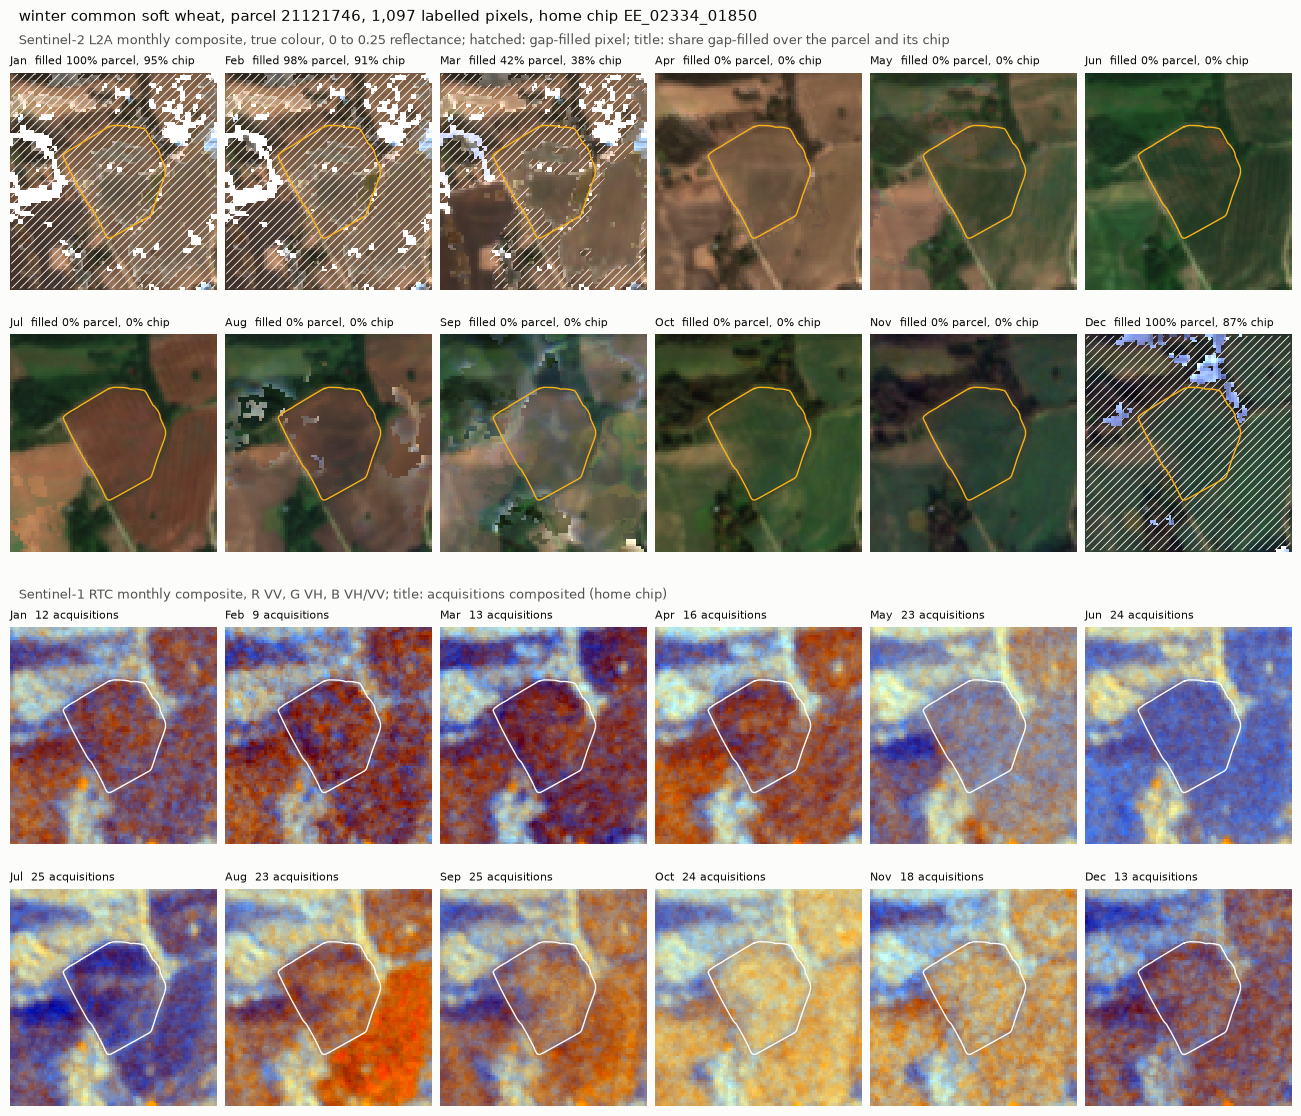

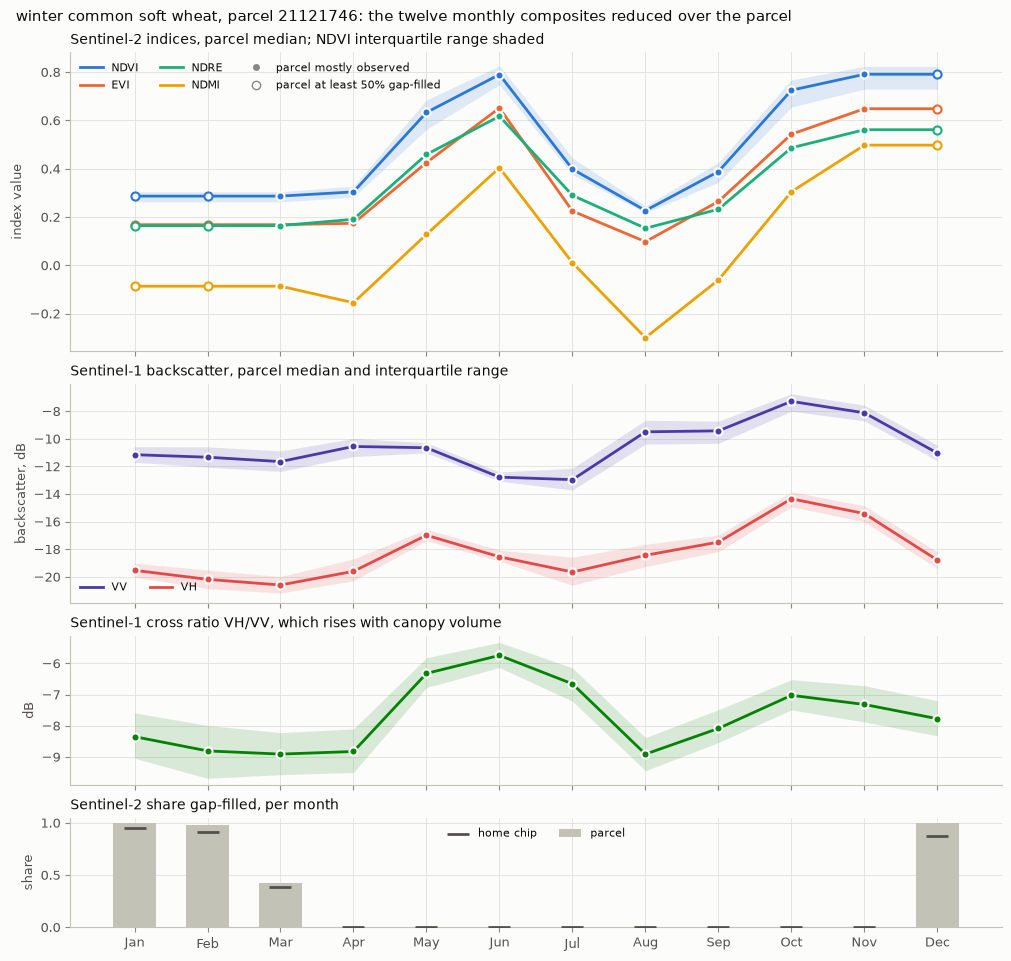

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
NDVI,0.287,0.287,0.287,0.304,0.633,0.790,0.398,0.227,0.389,0.725,0.791,0.791
EVI,0.168,0.168,0.168,0.174,0.426,0.652,0.225,0.098,0.265,0.543,0.649,0.649
NDRE,0.164,0.164,0.165,0.191,0.459,0.617,0.290,0.154,0.232,0.487,0.562,0.562
NDMI,-0.086,-0.086,-0.086,-0.155,0.128,0.404,0.011,-0.299,-0.060,0.305,0.498,0.498
VV,-11.148,-11.330,-11.648,-10.552,-10.646,-12.775,-12.958,-9.491,-9.421,-7.284,-8.116,-11.033
VH,-19.526,-20.181,-20.592,-19.599,-16.983,-18.548,-19.650,-18.439,-17.480,-14.342,-15.418,-18.788
VH/VV,-8.349,-8.806,-8.909,-8.825,-6.321,-5.743,-6.656,-8.910,-8.086,-7.023,-7.317,-7.775
s2_items,5,18,17,23,24,31,28,17,19,17,15,8
s2_clear_obs,0.092,0.176,1.757,14.178,13.295,23.619,19.480,7.227,5.948,8.824,3.175,0.326
s2_filled_chip,95%,91%,38%,0%,0%,0%,0%,0%,0%,0%,0%,87%


In [8]:
show_parcel(21121746)

### 3.2 winter rapeseed

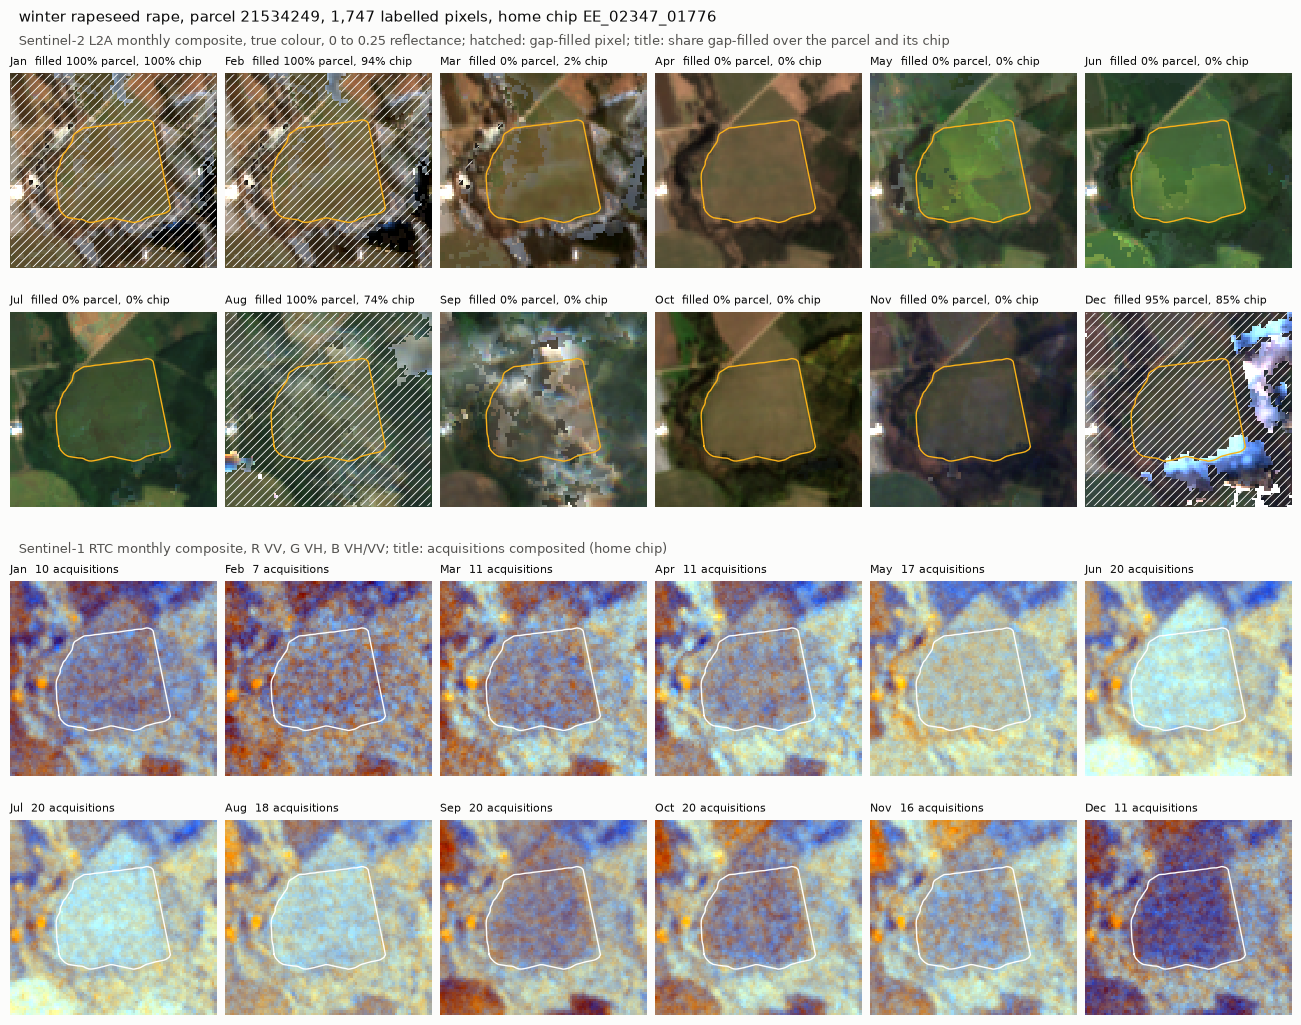

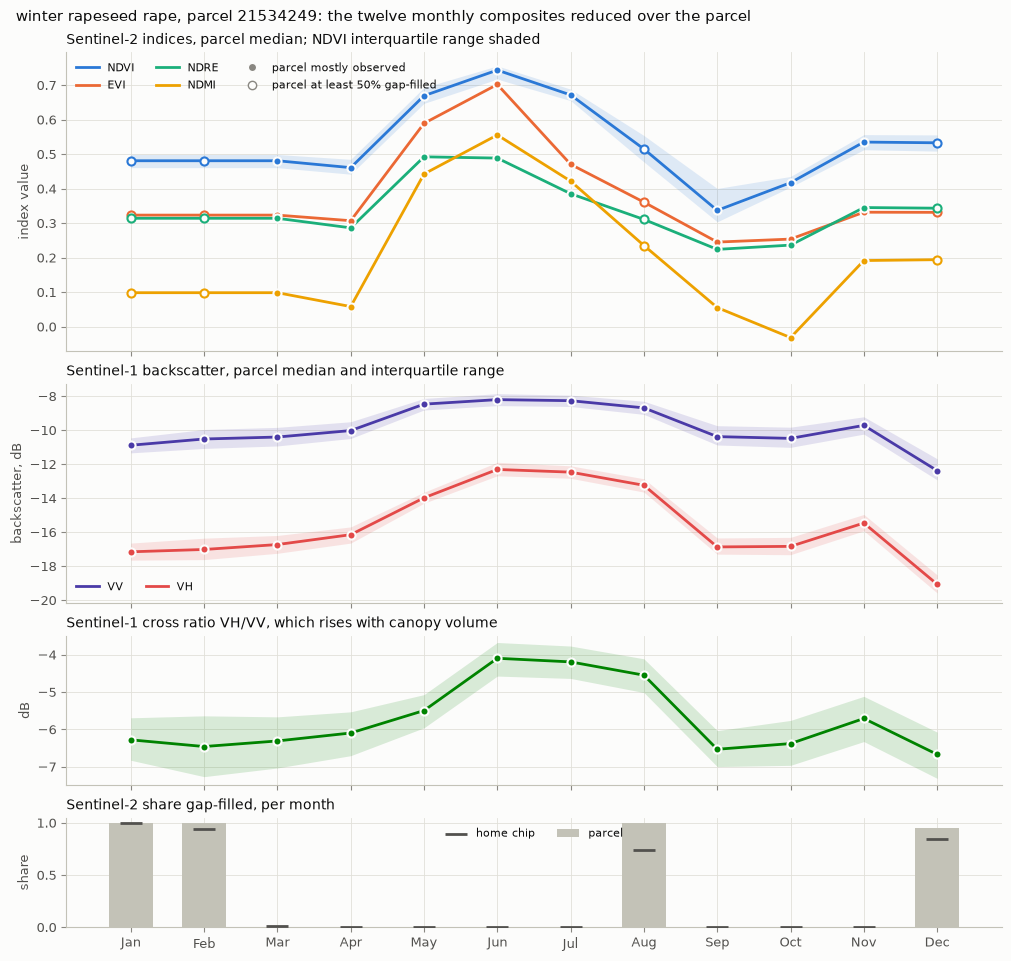

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
NDVI,0.481,0.481,0.481,0.461,0.670,0.744,0.672,0.515,0.337,0.418,0.535,0.533
EVI,0.324,0.324,0.324,0.307,0.590,0.702,0.471,0.361,0.245,0.254,0.332,0.332
NDRE,0.314,0.314,0.314,0.287,0.493,0.489,0.386,0.311,0.224,0.237,0.345,0.344
NDMI,0.099,0.099,0.099,0.058,0.443,0.556,0.422,0.235,0.056,-0.031,0.192,0.194
VV,-10.881,-10.513,-10.399,-10.018,-8.464,-8.198,-8.260,-8.683,-10.374,-10.478,-9.713,-12.373
VH,-17.149,-17.012,-16.723,-16.142,-13.973,-12.305,-12.463,-13.237,-16.862,-16.830,-15.456,-19.058
VH/VV,-6.278,-6.457,-6.308,-6.095,-5.494,-4.095,-4.191,-4.547,-6.531,-6.378,-5.707,-6.668
s2_items,2,5,7,9,8,9,10,4,7,4,4,8
s2_clear_obs,0.000,0.074,3.286,4.066,4.979,4.226,7.964,0.282,3.593,3.900,2.609,0.255
s2_filled_chip,100%,94%,2%,0%,0%,0%,0%,74%,0%,0%,0%,85%


In [9]:
show_parcel(21534249)

### 3.3 spring barley

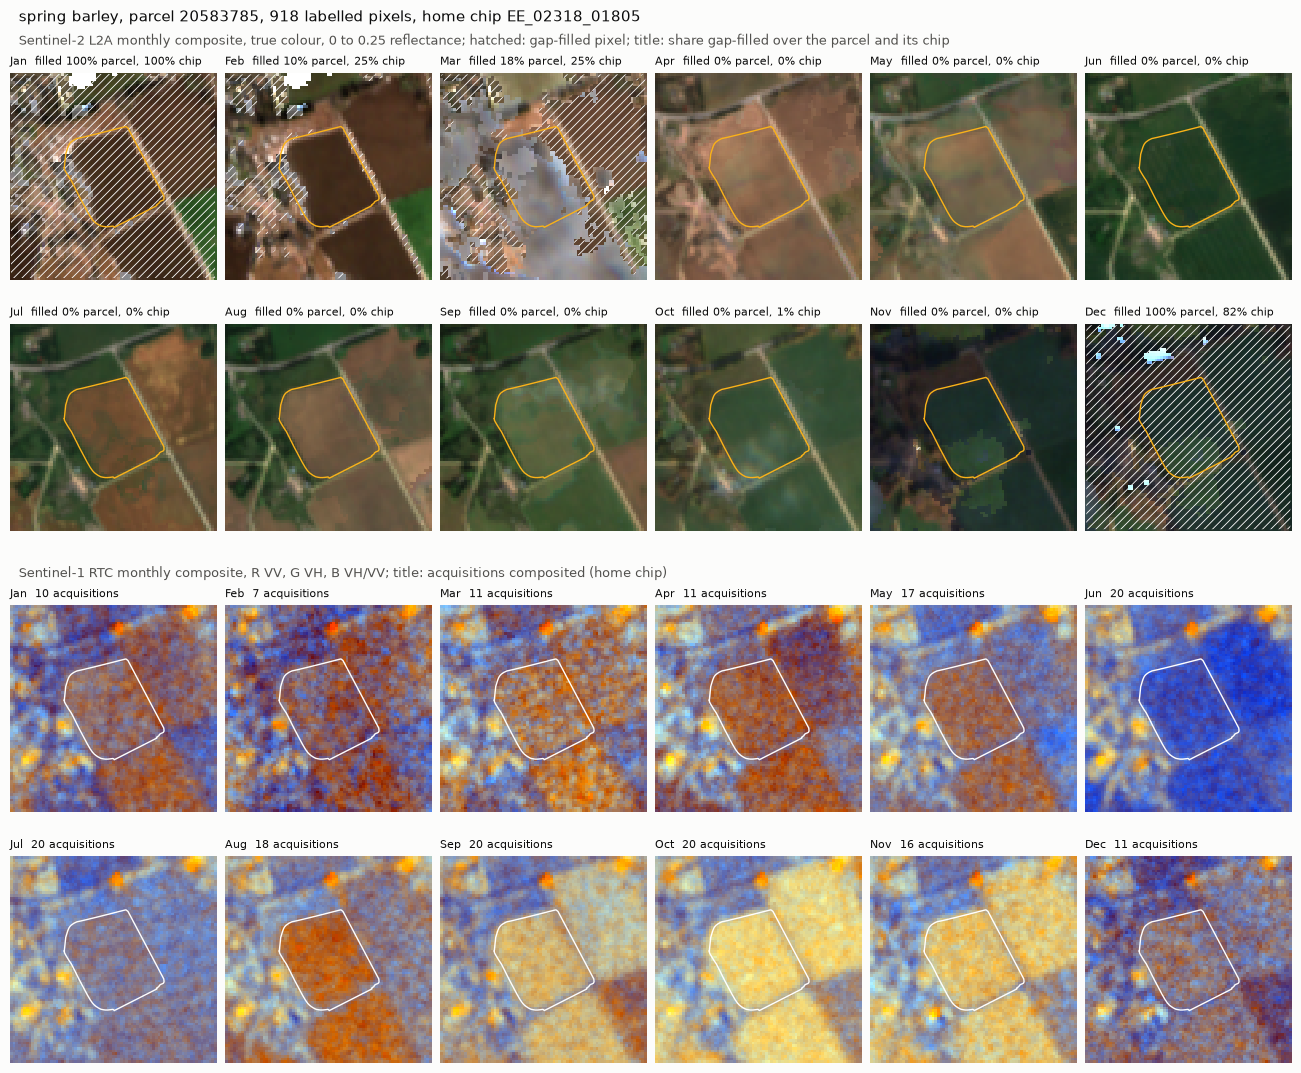

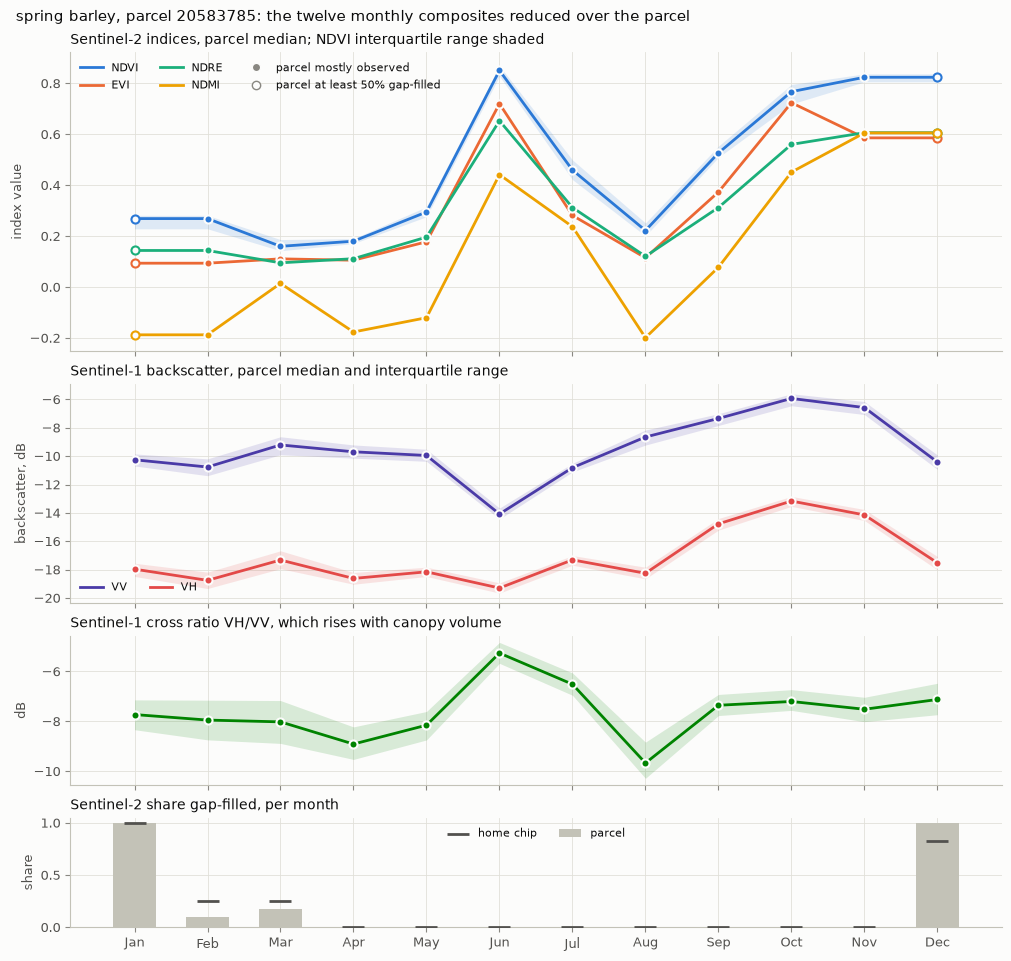

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
NDVI,0.269,0.269,0.160,0.180,0.295,0.851,0.460,0.222,0.527,0.767,0.824,0.824
EVI,0.094,0.094,0.111,0.106,0.178,0.720,0.281,0.115,0.373,0.724,0.586,0.586
NDRE,0.144,0.144,0.095,0.112,0.196,0.653,0.312,0.121,0.312,0.560,0.606,0.606
NDMI,-0.187,-0.187,0.014,-0.176,-0.120,0.442,0.237,-0.199,0.078,0.451,0.605,0.605
VV,-10.256,-10.767,-9.212,-9.694,-9.954,-14.079,-10.813,-8.652,-7.345,-5.933,-6.577,-10.417
VH,-17.967,-18.756,-17.323,-18.621,-18.154,-19.297,-17.312,-18.257,-14.773,-13.165,-14.144,-17.524
VH/VV,-7.727,-7.948,-8.020,-8.909,-8.153,-5.265,-6.513,-9.669,-7.356,-7.203,-7.516,-7.123
s2_items,1,7,8,8,8,11,10,6,6,4,4,2
s2_clear_obs,0.000,0.854,1.156,3.835,3.716,6.058,7.085,3.973,4.149,1.891,2.069,0.212
s2_filled_chip,100%,25%,25%,0%,0%,0%,0%,0%,0%,1%,0%,82%


In [10]:
show_parcel(20583785)

### 3.4 oats

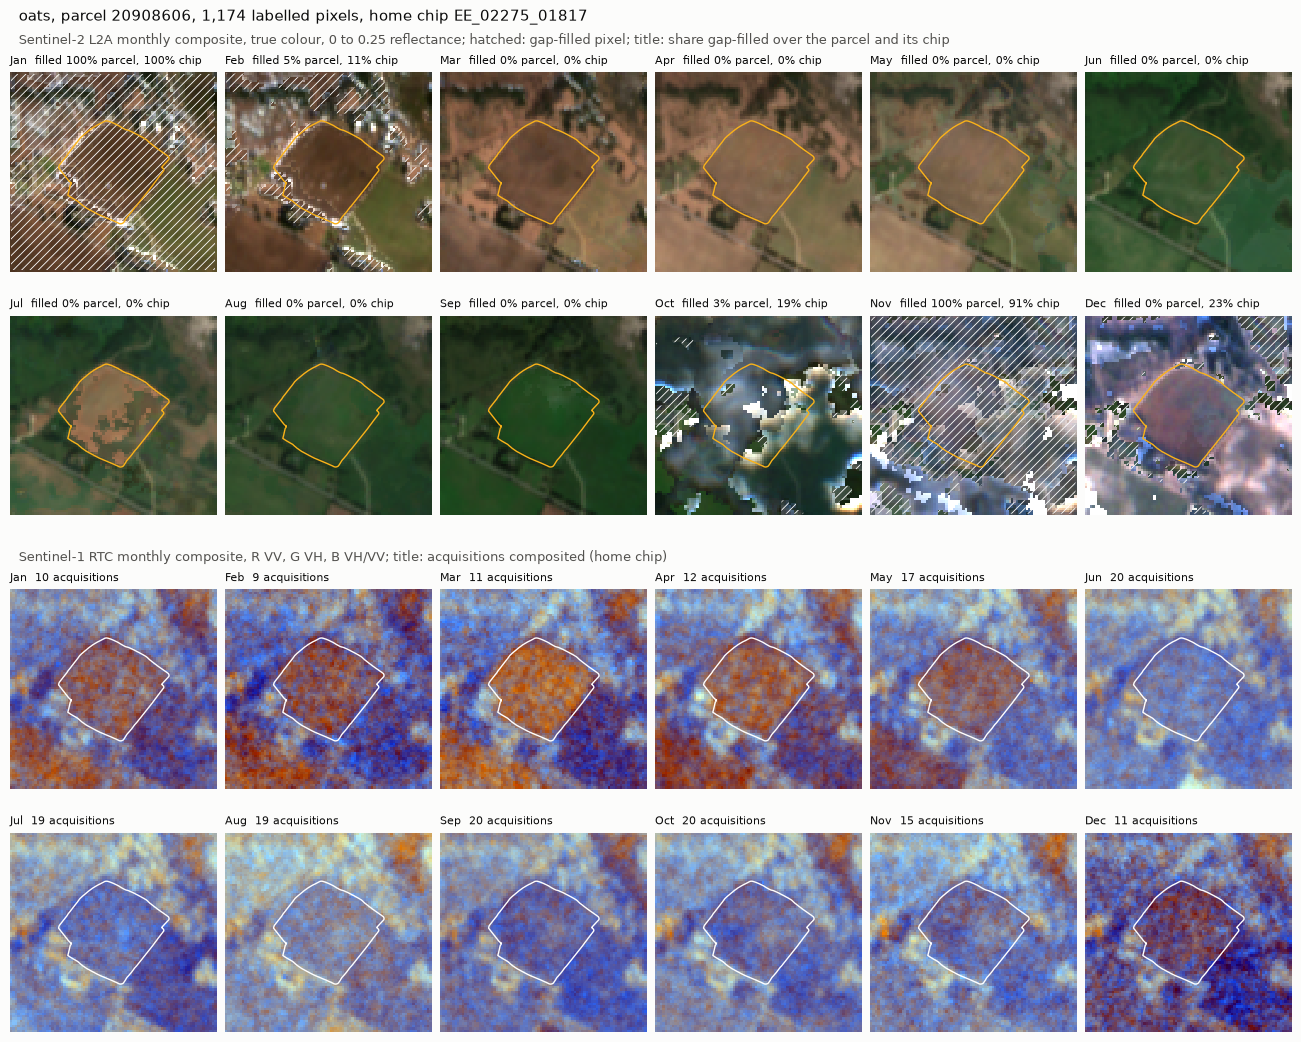

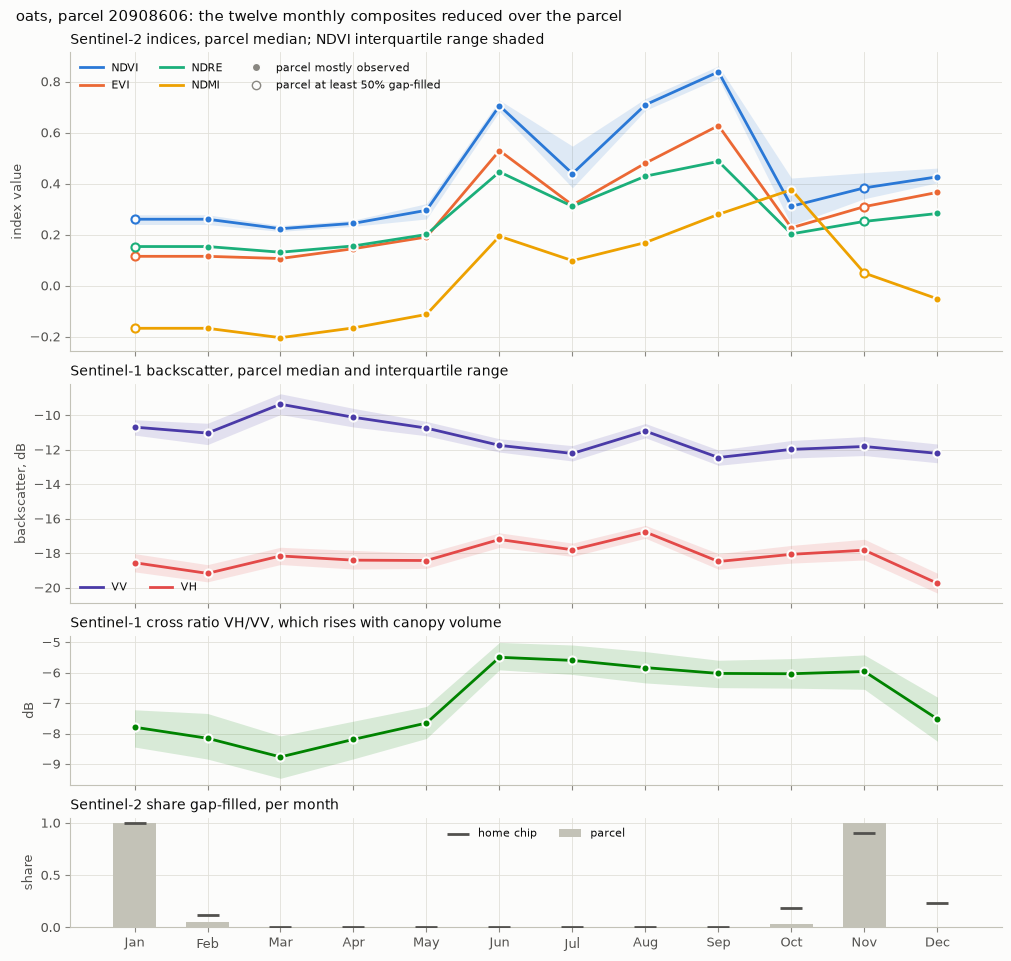

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
NDVI,0.260,0.260,0.223,0.244,0.295,0.705,0.439,0.709,0.838,0.311,0.383,0.426
EVI,0.115,0.115,0.106,0.145,0.190,0.529,0.316,0.480,0.627,0.227,0.310,0.365
NDRE,0.153,0.153,0.131,0.155,0.200,0.446,0.311,0.429,0.487,0.203,0.252,0.283
NDMI,-0.167,-0.167,-0.204,-0.166,-0.113,0.194,0.098,0.169,0.279,0.376,0.049,-0.052
VV,-10.692,-11.038,-9.364,-10.122,-10.749,-11.749,-12.220,-10.923,-12.454,-11.982,-11.815,-12.214
VH,-18.551,-19.171,-18.160,-18.404,-18.425,-17.205,-17.805,-16.773,-18.482,-18.067,-17.826,-19.748
VH/VV,-7.792,-8.157,-8.770,-8.193,-7.656,-5.495,-5.598,-5.834,-6.025,-6.036,-5.961,-7.524
s2_items,6,19,20,20,20,30,27,19,18,8,9,12
s2_clear_obs,0.000,3.162,10.645,16.937,15.905,23.350,11.718,14.694,15.534,1.788,0.158,2.455
s2_filled_chip,100%,11%,0%,0%,0%,0%,0%,0%,0%,19%,91%,23%


In [11]:
show_parcel(20908606)

### 3.5 potatoes

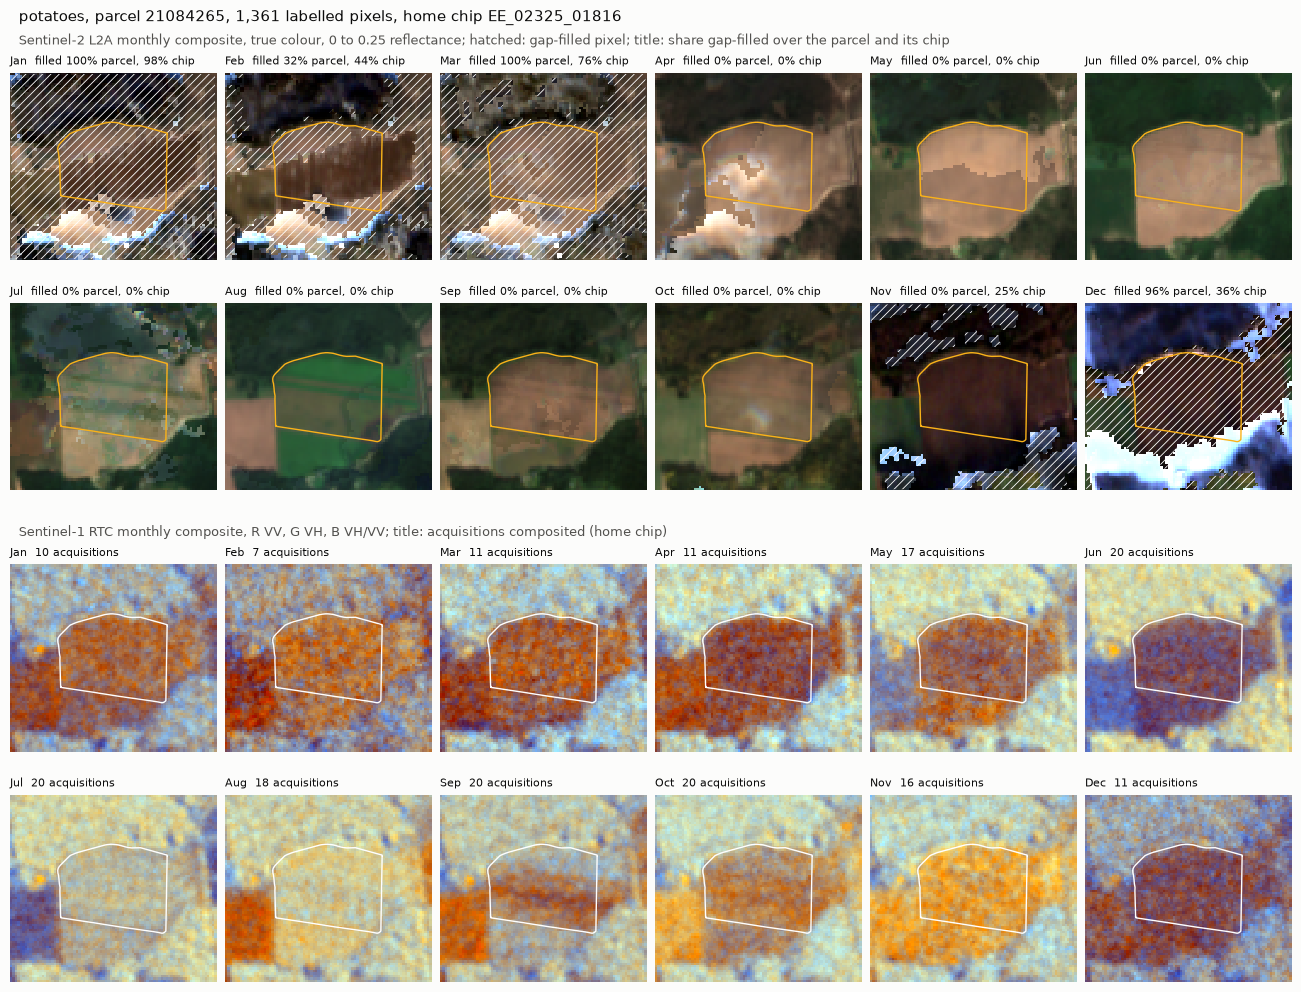

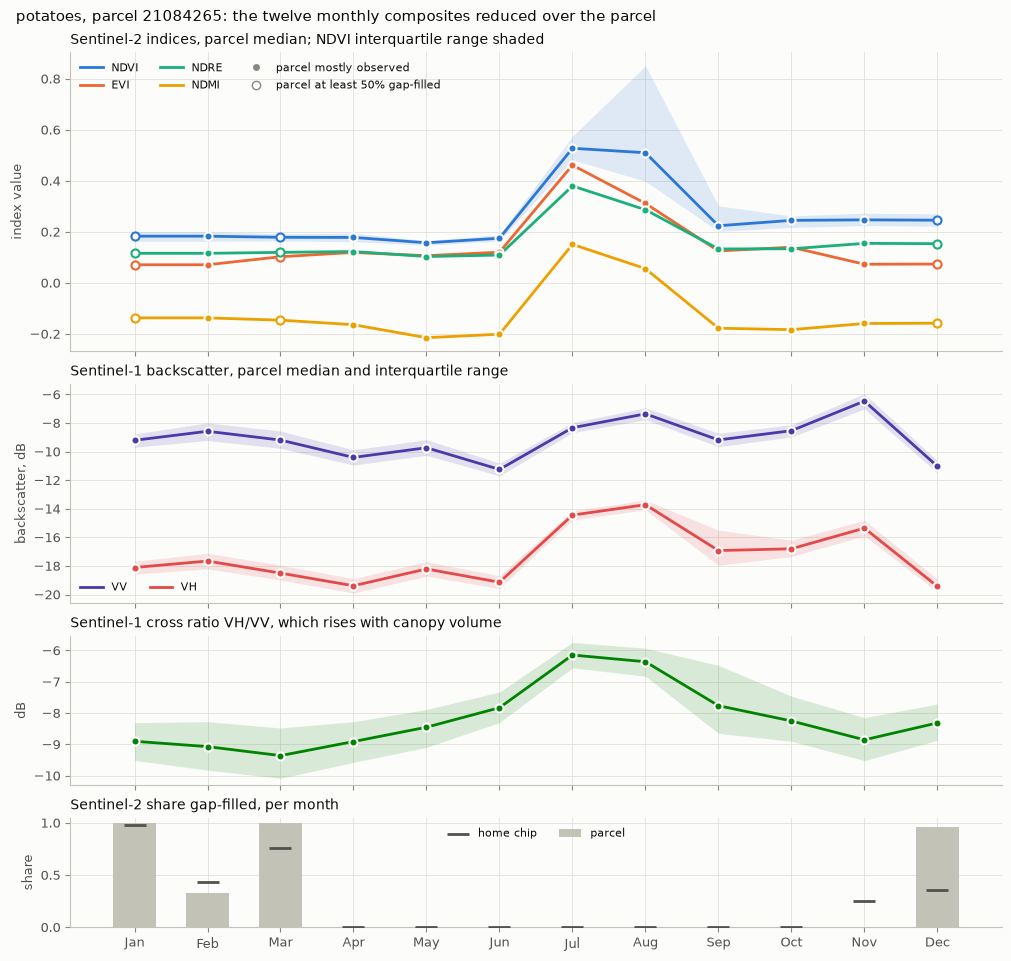

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
NDVI,0.183,0.183,0.179,0.178,0.157,0.175,0.528,0.510,0.224,0.245,0.247,0.246
EVI,0.071,0.071,0.103,0.119,0.107,0.120,0.461,0.311,0.125,0.140,0.073,0.074
NDRE,0.116,0.116,0.120,0.123,0.103,0.109,0.380,0.287,0.133,0.134,0.155,0.154
NDMI,-0.137,-0.137,-0.146,-0.164,-0.215,-0.201,0.151,0.056,-0.178,-0.183,-0.159,-0.158
VV,-9.208,-8.576,-9.191,-10.406,-9.726,-11.246,-8.328,-7.356,-9.182,-8.535,-6.465,-11.031
VH,-18.109,-17.657,-18.500,-19.386,-18.212,-19.139,-14.443,-13.712,-16.923,-16.800,-15.355,-19.435
VH/VV,-8.899,-9.071,-9.358,-8.909,-8.451,-7.828,-6.146,-6.361,-7.764,-8.252,-8.854,-8.314
s2_items,2,7,4,6,10,9,10,4,6,4,2,3
s2_clear_obs,0.020,1.095,0.489,2.306,3.658,7.887,5.473,3.105,4.847,1.847,0.746,1.011
s2_filled_chip,98%,44%,76%,0%,0%,0%,0%,0%,0%,0%,25%,36%


In [12]:
show_parcel(21084265)

### 3.6 grassland

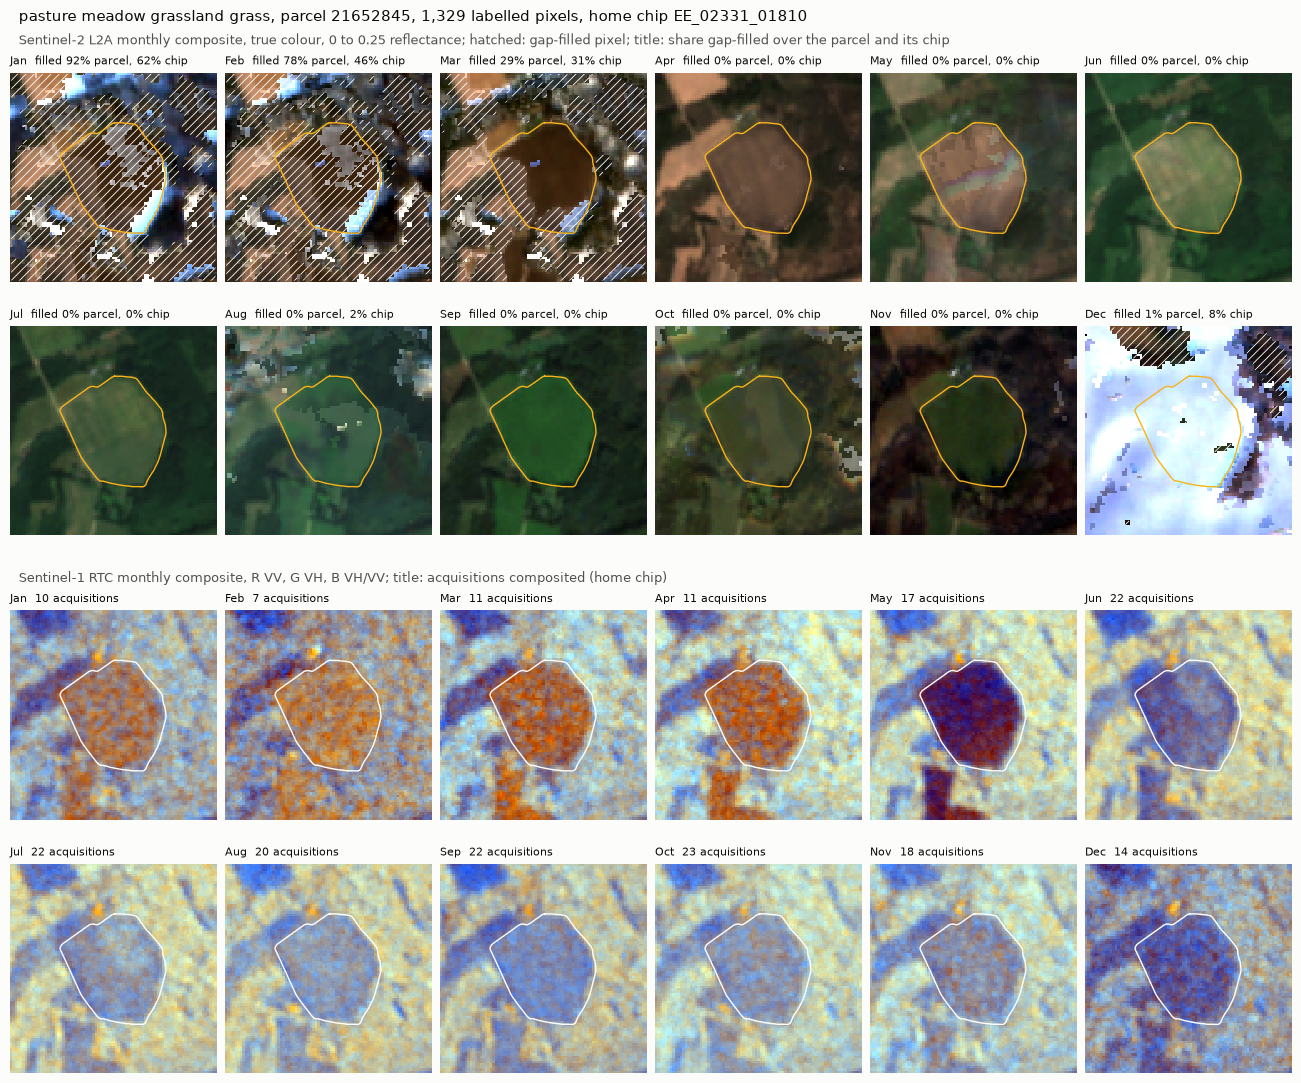

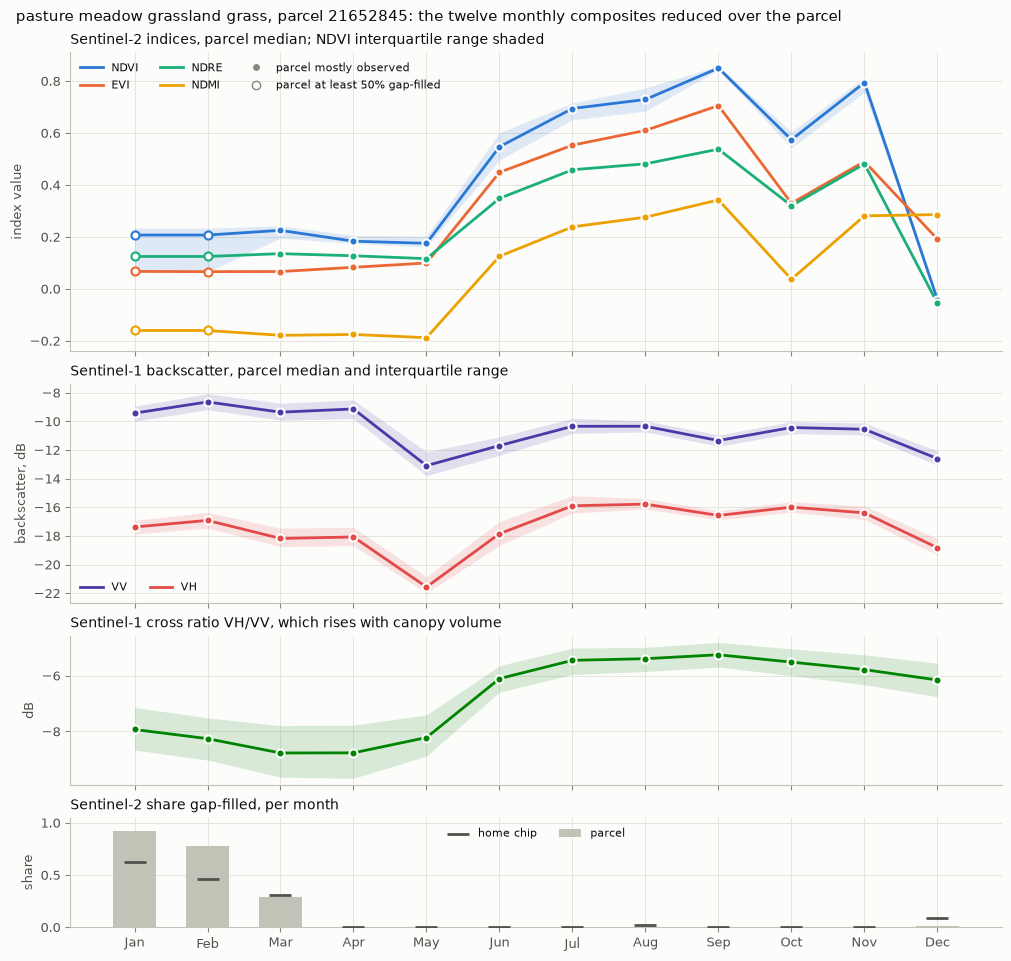

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
NDVI,0.207,0.207,0.225,0.184,0.176,0.547,0.694,0.729,0.850,0.574,0.794,-0.041
EVI,0.067,0.067,0.067,0.083,0.100,0.449,0.553,0.610,0.706,0.330,0.490,0.192
NDRE,0.125,0.125,0.136,0.128,0.117,0.348,0.459,0.482,0.538,0.320,0.481,-0.055
NDMI,-0.160,-0.160,-0.179,-0.175,-0.188,0.126,0.239,0.276,0.343,0.037,0.281,0.286
VV,-9.422,-8.639,-9.355,-9.129,-13.089,-11.687,-10.340,-10.338,-11.337,-10.425,-10.549,-12.598
VH,-17.374,-16.912,-18.173,-18.070,-21.563,-17.844,-15.892,-15.776,-16.568,-15.989,-16.386,-18.822
VH/VV,-7.928,-8.258,-8.771,-8.766,-8.217,-6.106,-5.450,-5.391,-5.250,-5.513,-5.783,-6.155
s2_items,4,9,8,11,12,15,16,7,10,6,5,8
s2_clear_obs,0.377,1.145,1.153,4.428,6.606,10.751,10.572,2.638,6.252,2.895,2.658,1.728
s2_filled_chip,62%,46%,31%,0%,0%,0%,0%,2%,0%,0%,0%,8%


In [13]:
show_parcel(21652845)

## 4. The six parcels on one axis

If the composites carry the phenology the encoder needs, the crops should already separate in twelve points: winter crops green from the first observed month, spring cereals greening in May and June, potatoes later, grassland green throughout. The radar panel shows whether VH carries the same ordering independently of the optical stack, which is the case for adding Sentinel-1 at all.

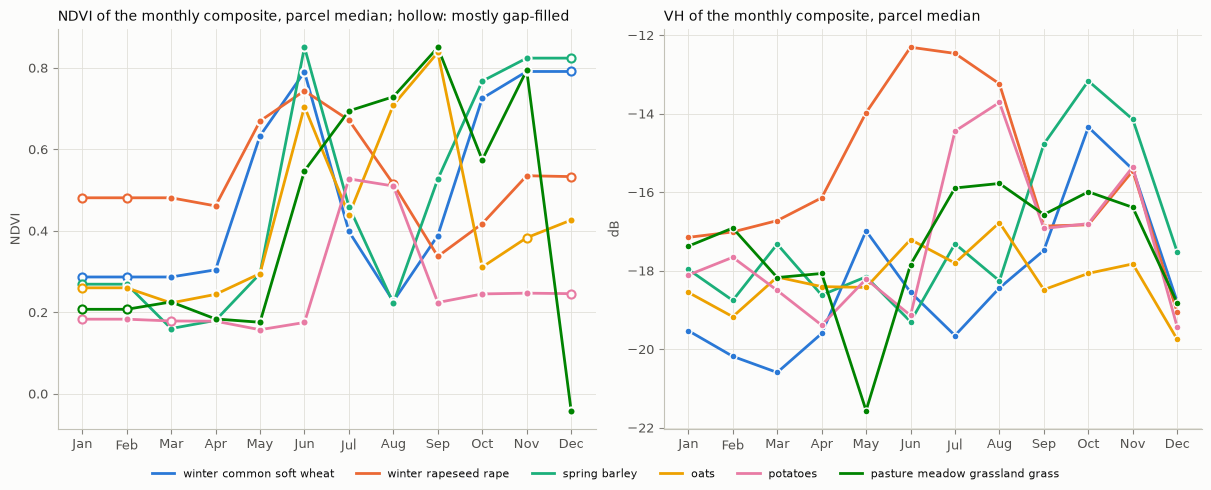

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8), sharex=True, layout="constrained")
x = np.arange(1, N_MONTHS + 1)
for (pid, p), color in zip(stacks.items(), SLOT):
    df = series[pid]
    hollow = df["s2_filled_parcel"].to_numpy() >= FILLED_HOLLOW
    label = p.crop.replace("_", " ")
    axes[0].plot(x, df["NDVI"], color=color, label=label, zorder=3)
    _markers(axes[0], x, df["NDVI"].to_numpy(), color, hollow)
    axes[1].plot(x, df["VH"], color=color, label=label, marker="o", ms=5, mec=SURFACE)
axes[0].set_title("NDVI of the monthly composite, parcel median; hollow: mostly gap-filled")
axes[0].set_ylabel("NDVI")
axes[1].set_title("VH of the monthly composite, parcel median")
axes[1].set_ylabel("dB")
for a in axes:
    a.set_xticks(x, MONTHS)
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside lower center", ncol=6, fontsize=8)
plt.show()

## 5. Composite against the acquisitions it summarises

The monthly median is a strong compression: a Baltic parcel has between 30 and 60 usable optical dates in a season and well over a hundred radar dates, and twelve values remain. This section pulls the individual acquisitions of two parcels with the loaders of notebook 05 and draws them behind the composite, so that what the median keeps and what it discards can be seen directly. It is the only section that reads from the Planetary Computer, and it takes about a minute per parcel. The default pair is the winter wheat, whose canopy peaks at the turn of May and June, and the potatoes, whose canopy closes for only three weeks across July and August.

The two sides are screened differently, and the difference is part of what is being looked at. The composite masks cloud **per pixel** with the scene classification and keeps every partially clear acquisition. The per-acquisition series drops a date unless 60 % of the parcel is clear, then takes the parcel median. A month in which the two disagree is a month where partial or misclassified cloud entered one side and not the other, or where the composite is interpolated. The radar acquisitions are shown as acquired, without the per-track offset removal of notebook 05, since the composite pools all tracks without it.

Each acquisition is placed at its day within the month, so a month's dots spread across the width that the composite point at its centre summarises.

In [15]:
from gfm4agri.data.parcel_explorer import explore, explore_s1

season = (f"{YEAR}-01-01", f"{YEAR}-12-31")
acquisitions = {}
for pid in FOCUS:
    s2x = explore(pid, YEAR, CC, season=season, animation=False, compare=False,
                  show=False, verbose=True)
    s1x = explore_s1(pid, YEAR, CC, season=season, animation=False, show=False, verbose=True)
    acquisitions[pid] = (s2x, s1x)
plt.close("all")  # the loaders draw their own charts; notebook 05 is where those are read

Parcel 21121746 (Estonia, 2021)
  crop  : winter common soft wheat (HCAT 3301010101), declared "Winter wheat"
  area  : 10.97 ha, 1,097 pixels at 10 m
  S2    : 2021-01-01 -> 2021-12-31 @10 m ...


  Found 276 candidate Sentinel-2 scenes
  Using EPSG:32635 for projection
  Filtering scenes: Cloud < 70%, Coverage >= 80%...
  Computing local cloud stats...
  Retained 80 scenes after local filtering (max 70%)


  baselines ['2.12', '3.00', '4.00'] via STAC item properties, 2 dates offset-corrected
  SCL blacklist removed: CLOUD_SHADOW 180px, CLOUD medium 2,457px, CLOUD high 4,385px, THIN_CIRRUS 539px, SNOW/ICE 18,745px


  dates : 56 usable, 9 dropped below 60 % clear, median 1099 valid px/date



wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21121746_2021/EE_21121746_2021_s2_indices.png


...

  dates : 32 usable, 5 dropped below 60 % clear, median 1364 valid px/date



wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21084265_2021/EE_21084265_2021_s2_indices.png


Parcel 21084265 (Estonia, 2021)
  crop  : potatoes (HCAT 3301030000)
  S1    : 2021-01-01 -> 2021-12-31 @10 m ...


  Found 181 sentinel-1-rtc scenes; tracks {'58 asc': 49, '160 asc': 46, '153 des': 43, '80 des': 43}; EPSG:32635
  Loading backscatter...
  dates : 181 acquisitions on tracks 58, 80, 153, 160


wrote /data/private/THESIS - ExplainedGMF4Agri/results/explore/EE_21084265_2021/EE_21084265_2021_s1_series.png


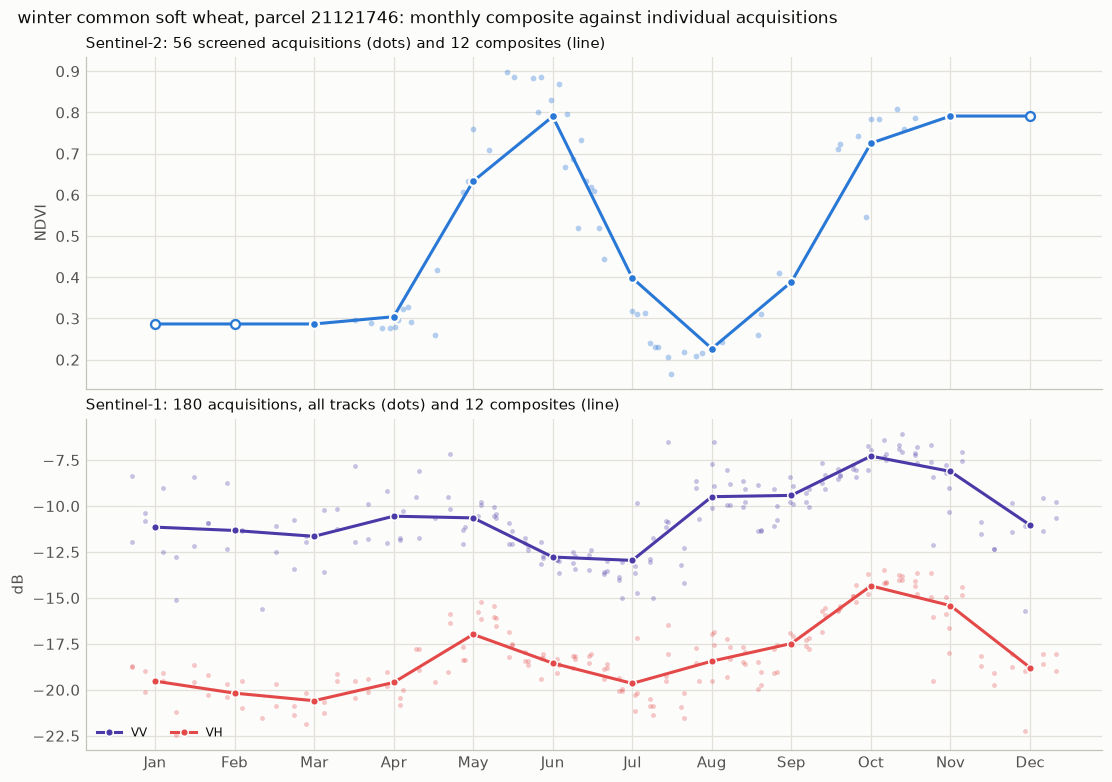

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
S2 dates,0,0,0,9,7,13,11,4,3,8,1,0
"NDVI acquisitions, median",,,,0.292,0.633,0.796,0.311,0.217,0.312,0.751,0.786,
NDVI composite,0.287,0.287,0.287,0.304,0.633,0.790,0.398,0.227,0.389,0.725,0.791,0.791
S1 dates,10,7,10,12,18,19,20,18,20,20,16,10
"VH acquisitions, median",-19.309,-20.260,-20.789,-19.654,-16.715,-18.348,-19.725,-18.414,-17.573,-14.268,-14.958,-18.849
VH composite,-19.526,-20.181,-20.592,-19.599,-16.983,-18.548,-19.650,-18.439,-17.480,-14.342,-15.418,-18.788
NDVI difference,,,,0.013,0.001,-0.006,0.087,0.010,0.077,-0.026,0.005,
VH difference,-0.217,0.079,0.197,0.055,-0.269,-0.201,0.075,-0.025,0.093,-0.075,-0.460,0.062
S2 parcel filled,100%,98%,42%,0%,0%,0%,0%,0%,0%,0%,0%,100%


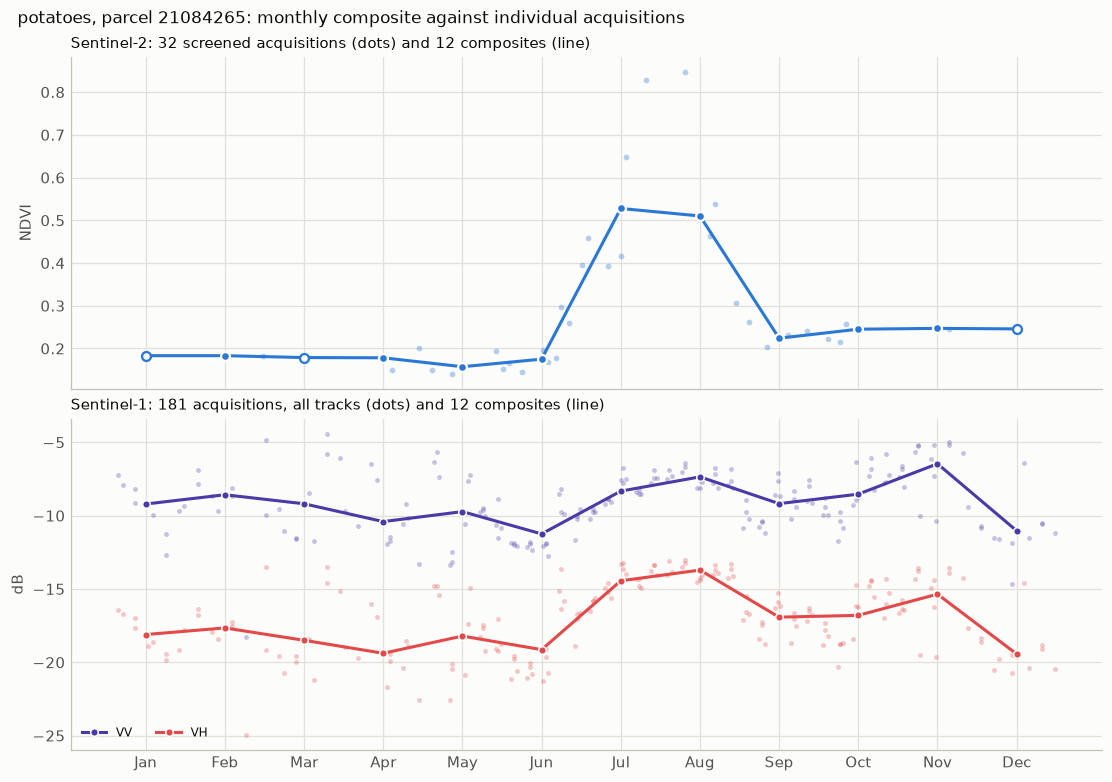

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
S2 dates,0,1,0,2,3,8,6,4,4,3,1,0
"NDVI acquisitions, median",,0.182,,0.175,0.150,0.173,0.438,0.501,0.236,0.223,0.246,
NDVI composite,0.183,0.183,0.179,0.178,0.157,0.175,0.528,0.510,0.224,0.245,0.247,0.246
S1 dates,10,7,11,11,17,20,20,18,20,20,16,11
"VH acquisitions, median",-18.210,-17.497,-19.158,-19.460,-18.277,-19.610,-14.486,-13.887,-16.751,-16.629,-15.351,-19.471
VH composite,-18.109,-17.657,-18.500,-19.386,-18.212,-19.139,-14.443,-13.712,-16.923,-16.800,-15.355,-19.435
NDVI difference,,0.002,,0.003,0.007,0.002,0.090,0.009,-0.012,0.022,0.001,
VH difference,0.101,-0.160,0.657,0.074,0.065,0.471,0.043,0.175,-0.172,-0.170,-0.003,0.036
S2 parcel filled,100%,32%,100%,0%,0%,0%,0%,0%,0%,0%,0%,96%


In [16]:
def month_x(dates) -> np.ndarray:
    # A date as a position on the month axis: month m spans m - 0.5 to m + 0.5.
    d = pd.DatetimeIndex(pd.to_datetime(dates))
    return (d.month + (d.day - 0.5) / d.days_in_month - 0.5).to_numpy()


def against_acquisitions(pid: int) -> None:
    if pid not in stacks:
        stacks[pid] = load_parcel(pid)
        series[pid] = parcel_series(stacks[pid])
    p, df = stacks[pid], series[pid]
    acq_s2, acq_s1 = acquisitions[pid]
    s2_acq = (acq_s2.table[["date", "NDVI"]].dropna()
              .assign(date=lambda t: pd.to_datetime(t.date), x=lambda t: month_x(t.date)))
    s1_acq = (acq_s1.features.rename(columns={"vv_median_db": "VV", "vh_median_db": "VH"})
              [["date", "VV", "VH"]]
              .assign(date=lambda t: pd.to_datetime(t.date), x=lambda t: month_x(t.date)))

    x = np.arange(1, N_MONTHS + 1)
    hollow = df["s2_filled_parcel"].to_numpy() >= FILLED_HOLLOW
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True, layout="constrained")
    fig.suptitle(f"{p.crop.replace('_', ' ')}, parcel {p.parcel_id}: monthly composite against "
                 "individual acquisitions", x=0.01, ha="left", fontsize=11)
    ax = axes[0]
    ax.scatter(s2_acq.x, s2_acq.NDVI, s=14, color=SLOT[0], alpha=0.35, lw=0, zorder=2)
    ax.plot(x, df["NDVI"], color=SLOT[0], zorder=3)
    _markers(ax, x, df["NDVI"].to_numpy(), SLOT[0], hollow)
    ax.set_ylabel("NDVI")
    ax.set_title(f"Sentinel-2: {len(s2_acq)} screened acquisitions (dots) and 12 composites (line)")
    ax = axes[1]
    for name, color in (("VV", SLOT[6]), ("VH", SLOT[7])):
        ax.scatter(s1_acq.x, s1_acq[name], s=10, color=color, alpha=0.3, lw=0, zorder=2)
        ax.plot(x, df[name], color=color, marker="o", ms=5, mec=SURFACE, label=name, zorder=3)
    ax.set_ylabel("dB")
    ax.set_title(f"Sentinel-1: {len(s1_acq)} acquisitions, all tracks (dots) and 12 composites (line)")
    ax.legend(loc="lower left", ncol=2, fontsize=8)
    ax.set_xticks(x, MONTHS)
    plt.show()

    monthly = pd.DataFrame({
        "S2 dates": s2_acq.groupby(s2_acq.date.dt.month).size(),
        "NDVI acquisitions, median": s2_acq.groupby(s2_acq.date.dt.month).NDVI.median(),
        "NDVI composite": df["NDVI"],
        "S1 dates": s1_acq.groupby(s1_acq.date.dt.month).size(),
        "VH acquisitions, median": s1_acq.groupby(s1_acq.date.dt.month).VH.median(),
        "VH composite": df["VH"],
    }).reindex(x)
    monthly["NDVI difference"] = monthly["NDVI composite"] - monthly["NDVI acquisitions, median"]
    monthly["VH difference"] = monthly["VH composite"] - monthly["VH acquisitions, median"]
    monthly[["S2 dates", "S1 dates"]] = monthly[["S2 dates", "S1 dates"]].fillna(0)
    monthly["S2 parcel filled"] = df["s2_filled_parcel"]
    show_months(monthly)


for pid in FOCUS:
    against_acquisitions(pid)

## 6. What the encoder finally receives

Before the backbone, each band is standardised with the statistics the encoder was **pretrained** under, `normalisation="backbone"` in `EuroCropsSegDataModule`. A Sentinel-1 pixel that was never observed enters at the band mean, which standardises to zero. The heatmaps show, for the first parcel of `FOCUS`, the parcel median of the standardised value per band and month. Values within about plus or minus two are inside the pretraining distribution; a band that sits far outside it in every month points at a units or offset mismatch rather than at the crop, and this is where it would show.

Two things to keep in mind when reading them. Prithvi was pretrained on HLS, so its statistics describe a different sensor harmonisation and a different archive, and a systematic shift there is expected rather than alarming. And the `_tl` variants of Prithvi are told each composite's date as the 15th of its month, printed below, which is a convention of this pipeline rather than the date of any acquisition.

This cell imports TerraTorch for the pretraining statistics, which takes about 30 seconds warm on the JupyterHub machine and several minutes on the first import after an install.

/home/jovyan/.cache/pypoetry/virtualenvs/gfm4agri-7U2rqC_9-py3.11/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


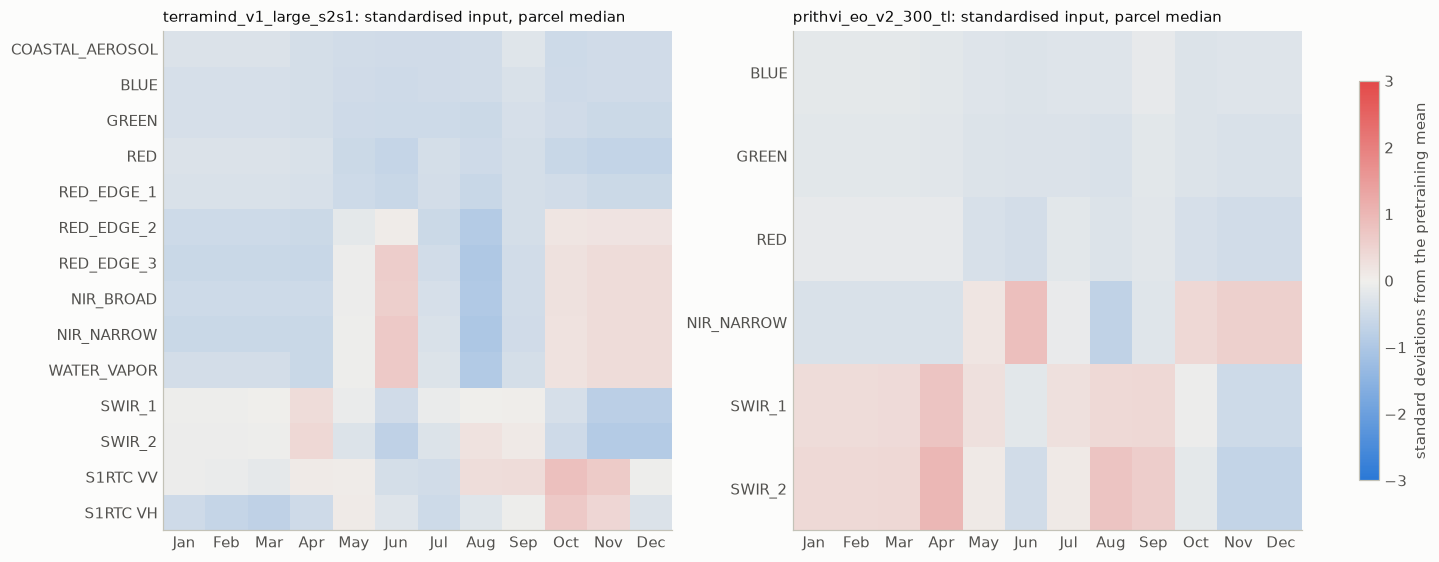

terramind_v1_large_s2s1: bands outside +-2 in at least 6 of 12 months: none
prithvi_eo_v2_300_tl: bands outside +-2 in at least 6 of 12 months: none

prithvi _tl temporal_coords (year, zero-based day of year):
[[2021, 14], [2021, 45], [2021, 73], [2021, 104], [2021, 134], [2021, 165], [2021, 195], [2021, 226], [2021, 257], [2021, 287], [2021, 318], [2021, 348]]


In [17]:
from gfm4agri.benchmark.backbones import get_backbone
from gfm4agri.benchmark.segmentation_data import monthly_temporal_coords

p = stacks[FOCUS[0]]
diverging = LinearSegmentedColormap.from_list("blue_grey_red", [SLOT[0], "#f0efec", SLOT[7]])


def standardised(arr, means, stds):
    m = np.asarray(means, np.float32)[None, :, None]
    s = np.asarray(stds, np.float32)[None, :, None]
    return (arr - m) / s


def encoder_view(name: str) -> pd.DataFrame:
    # Parcel median of the standardised input per band and month, as the datamodule builds it.
    spec = get_backbone(name)
    bands = list(spec.input_bands or BAND_NAMES)
    means, stds = spec.stats(bands)
    s2 = p.s2[:, [BAND_NAMES.index(b) for b in bands]][:, :, p.inside]
    parts, labels = [standardised(s2, means, stds)], list(bands)
    for mod, meta in spec.extra_modalities.items():
        mm, ss = meta["stats"](list(meta["bands"]))
        s1 = p.s1[:, :, p.inside]
        s1 = np.where(np.isfinite(s1), s1, np.asarray(mm, np.float32)[None, :, None])
        parts.append(standardised(s1, mm, ss))
        labels += [f"{mod} {b}" for b in meta["bands"]]
    z = np.concatenate(parts, axis=1)
    return pd.DataFrame(np.median(z, axis=2).T, index=labels, columns=MONTHS)


views = {n: encoder_view(n) for n in ("terramind_v1_large_s2s1", "prithvi_eo_v2_300_tl")}
fig, axes = plt.subplots(1, 2, figsize=(13, 5), layout="constrained",
                         gridspec_kw={"width_ratios": [1, 1]})
for ax, (name, z) in zip(axes, views.items()):
    im = ax.imshow(z.to_numpy(), cmap=diverging, vmin=-3, vmax=3, aspect="auto")
    ax.set_yticks(range(len(z)), z.index)
    ax.set_xticks(range(N_MONTHS), MONTHS)
    ax.grid(False)
    ax.set_title(f"{name}: standardised input, parcel median")
fig.colorbar(im, ax=axes, shrink=0.8, label="standard deviations from the pretraining mean")
plt.show()

for name, z in views.items():
    print(f"{name}: bands outside +-2 in at least 6 of 12 months:",
          [b for b in z.index if (z.loc[b].abs() > 2).sum() >= 6] or "none")
print("\nprithvi _tl temporal_coords (year, zero-based day of year):")
print(monthly_temporal_coords(YEAR).astype(int).tolist())

## 7. What the default parcels show

These observations are read from the outputs above for the six default parcels in 2021. They describe these parcels, not Estonia as a whole.

1. **The winter months are interpolations.** Over the parcels' own pixels, January is gap-filled for between 92 and 100 % of every parcel, and December for 95 to 100 % of four of the six. The few pixels counted as observed in those months are mostly bright, snow or cloud that the scene classification accepted as clear, scattered through an otherwise interpolated image. Where December is observed it is not necessarily a usable surface: the grassland parcel's December composite is snow, at NDVI -0.04, and the oats parcel is surrounded by white patches of snow or cloud.
2. **A filled share of zero does not mean a clean month.** Residual cloud and haze survive the per-pixel screening in months reported as fully observed: September for the wheat and the rapeseed, October for the oats, April for the potatoes, and a coloured fringe across the grassland in May. The filled share cannot detect these, and only the image sheets show them. For the wheat, the composite sits 0.09 NDVI above the median of the screened acquisitions in July and 0.08 in September.
3. **The per-pixel median leaves seams.** Each pixel takes its median over its own set of clear acquisitions, so a cloud edge on a single date becomes a straight boundary inside a field. The oats parcel in July and the rapeseed in March split into two tones along lines that are not field boundaries.
4. **Peaks shorter than a month are diluted.** The potato canopy stayed above NDVI 0.8 for about three weeks, from late July to 10 August, while its July and August composites hold 0.53 and 0.51. The wheat reached about 0.89 at the turn of May and June, against composites of 0.63 and 0.79. In August the potato composite agrees with the median of that month's acquisitions, 0.51 against 0.50, so the dilution is the median doing what it is meant to do rather than a fault. An encoder given these stacks never sees either peak, so any separation between crops that rests on peak height is weaker in the composites than in the acquisitions.
5. **The radar stack is complete.** Every pixel of every parcel is observed in every month, and the cross ratio VH/VV follows the canopy in months where the optical stack is interpolated or contaminated: it rises with the rapeseed from April to June and falls after the wheat harvest.
6. **The inputs sit inside the pretraining distributions.** For the wheat parcel, no band of either backbone lies more than two standard deviations from its pretraining mean in six or more months, so nothing points to a units or offset mismatch between the export and the encoders.

## 8. Using it on other parcels

`show_parcel(pid)` takes any parcel in an exported chip and loads it on demand; changing `PARCEL_IDS` in section 2 changes the summary table and the overview of section 4. Parcels of one class can be drawn from the chip index, for example the twenty largest single-chip clover parcels:

```python
k = CLASSES.index("clover")
one_chip = chip_parcels.groupby("parcel_id").chip_id.transform("nunique") == 1
cands = chip_parcels[one_chip & (chip_parcels.class_index == k)].nlargest(20, "pixels")
```

`FOCUS` lists the parcels compared against their acquisitions in section 5, and `MARGIN_PX`, `RGB_MAX` and `S1_STRETCH` change the context and the stretches of the image sheets.